# ISLR101 — Lightweight Pose-Based Sign Recognition

Reproduction of the released baseline, reconstruction of the official CSV split on the released pose samples, and evaluation of lightweight LSTM variants.


## 1. Environment


In [1]:
import sys
import torch
import numpy as np
import pandas as pd
from pathlib import Path
import shutil
import os

print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Python: 3.12.13
PyTorch: 2.10.0+cu128
CUDA: True
GPU: Tesla T4


## 2. Dependencies


In [2]:
!pip install -q \
    configargparse \
    tensorboardX \
    adamod \
    pyyaml \
    networkx \
    scikit-learn \
    matplotlib \
    tqdm \
    gdown


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 2.6 MB/s eta 0:00:00


## 3. Restore project files


In [3]:
from pathlib import Path
import shutil

# Locate and restore the project

candidates = []

for main_file in Path("/kaggle/input").rglob("main.py"):
    p = main_file.parent
    if (p / "config").exists() and (p / "st_gcn").exists():
        candidates.append(p)

assert len(candidates) >= 1, "ISLR101 project not found"

SRC = candidates[0]
DEST = Path("/kaggle/working/ISLR101")

if DEST.exists():
    shutil.rmtree(DEST)

shutil.copytree(SRC, DEST)

os.chdir(DEST)

print("Project restored:", DEST)


Project restored: /kaggle/working/ISLR101


In [4]:
from pathlib import Path
import shutil

project = Path("/kaggle/working/ISLR101")

ranjbar_files = [
    p for p in Path("/kaggle/input").rglob("*.py")
    if "ranjbar" in str(p).lower()
]

print("Candidates:", ranjbar_files)

assert len(ranjbar_files) >= 1

ranjbar_main = ranjbar_files[0]

shutil.copy2(
    project / "main.py",
    project / "main_github_original.py"
)

shutil.copy2(
    ranjbar_main,
    project / "main.py"
)

print("Ranjbar main.py restored")


Candidates: [PosixPath('/kaggle/input/datasets/shokufashalchi/main-ranjbar/main_ranjbar.py')]
Ranjbar main.py restored


### Compatibility patches


In [5]:
from pathlib import Path
import shutil

# Backup the author-provided main.py
# PyTorch compatibility fixes
# Feeder import compatibility

project = Path("/kaggle/working/ISLR101")

main_path = project / "main.py"
backup = project / "main_ranjbar_original.py"

if not backup.exists():
    shutil.copy2(main_path, backup)

text = main_path.read_text()

text = text.replace(
    ",\n                    volatile=True",
    ""
)

if "@torch.no_grad()\n    def test(" not in text:
    text = text.replace(
        "    def test(self, epoch, save_score=True, loader_name=['test']):",
        "    @torch.no_grad()\n"
        "    def test(self, epoch, save_score=True, loader_name=['test']):"
    )

text = text.replace(
    "step = (epoch + 1) * (len(self.data_loader['train']))",
    "step = epoch + 1"
)

main_path.write_text(text)

feeder_path = project / "st_gcn/feeder/feeder_islr.py"

feeder_text = feeder_path.read_text()

feeder_text = feeder_text.replace(
    "from .feeder import tools",
    "from . import tools"
)

feeder_path.write_text(feeder_text)

print("Compatibility patches applied")


Compatibility patches applied


## 4. Reproduce the published ST-TR-1s checkpoint


In [6]:
%cd /kaggle/working/ISLR101

!python main.py \
    --config ./config/test_sttr1s.yaml \
    --work-dir ./experiments/sttr1s_official \
    --phase test \
    --num-worker 4


/kaggle/working
False
Pad Temporal  4
Pad Temporal  4
Pad Temporal  4
Pad Temporal  0
Pad Temporal  0
Pad Temporal  0
Pad Temporal  0
Pad Temporal  4
Pad Temporal  4
Pad Temporal  4
Pad Temporal  0
Pad Temporal  0
Pad Temporal  0
Pad Temporal  0
Pad Temporal  4
[ Mon Sep 14 10:38:12 2026 ] Load weights from ./checkpoints/sttr1s.pt.
Params:  1977845
Layer params:  1977845
[ Mon Sep 14 10:38:16 2026 ] Model:   st_gcn.net.ST_GCN.
[ Mon Sep 14 10:38:16 2026 ] Weights: ./checkpoints/sttr1s.pt.
[ Mon Sep 14 10:38:16 2026 ] Eval epoch: 1
[ Mon Sep 14 10:38:25 2026 ] 	Mean test loss of 113 batches: 0.665591912200897.
[ Mon Sep 14 10:38:25 2026 ] 	Top1: 89.81%
[ Mon Sep 14 10:38:25 2026 ] 	Top5: 96.57%

Testing: Epoch [0/120], Samples [811.0/903], Loss: 0.665591912200897, Testing Accuracy: 89.81173864894795

Testing: Epoch [0/120], Samples [811.0/903], Loss: 0.665591912200897, Testing Accuracy: 89.81173864894795
[ Mon Sep 14 10:38:25 2026 ] Done.



The author-provided `main.py` is used with minimal compatibility fixes for the current Kaggle/PyTorch environment.


## 5. Load released pose arrays

The released `train` and `test` pose files are treated as storage containers. The official split is reconstructed later using sample IDs.


In [7]:
import numpy as np
from pathlib import Path

data_root = Path("/kaggle/working/ISLR101/data")

X_train = np.load(
    data_root / "islr101_train.npy",
    mmap_mode="r"
)

y_train = np.load(
    data_root / "islr101_train_label.npy"
)

X_test = np.load(
    data_root / "islr101_test.npy",
    mmap_mode="r"
)

y_test = np.load(
    data_root / "islr101_test_label.npy"
)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

print("Classes:", len(np.unique(y_train)))


X_train: (3609, 3, 112, 67, 1)
y_train: (3609,)
X_test : (903, 3, 112, 67, 1)
y_test : (903,)
Classes: 101


## 6. Audit released pose samples against the official CSV split


In [8]:
from pathlib import Path
import numpy as np
import pandas as pd

# Locate official split CSVs
# Normalize sample IDs
# Compare released pose IDs with the official split

repo_root = Path("/kaggle/working/ISLR101")
data_root = repo_root / "data"

csv_files = list(Path("/kaggle/input").rglob("*_dataset.csv"))

train_csv_path = next(p for p in csv_files if p.name == "train_dataset.csv")
val_csv_path   = next(p for p in csv_files if p.name == "val_dataset.csv")
test_csv_path  = next(p for p in csv_files if p.name == "test_dataset.csv")

print("Official CSVs:")
print("Train:", train_csv_path)
print("Val  :", val_csv_path)
print("Test :", test_csv_path)

official_train = pd.read_csv(train_csv_path)
official_val   = pd.read_csv(val_csv_path)
official_test  = pd.read_csv(test_csv_path)

print("\nOfficial sizes:")
print("Train:", len(official_train))
print("Val  :", len(official_val))
print("Test :", len(official_test))
print("Total:", len(official_train) + len(official_val) + len(official_test))


def normalize_id(x):
    if isinstance(x, bytes):
        x = x.decode("utf-8")

    x = str(x).strip()

    if x.lower().endswith(".mp4"):
        x = x[:-4]

    x = x.replace("\\", "_")
    x = x.replace("/", "_")

    return x


official_train_ids = set(
    official_train["id"].map(normalize_id)
)

official_val_ids = set(
    official_val["id"].map(normalize_id)
)

official_test_ids = set(
    official_test["id"].map(normalize_id)
)

official_all_ids = (
    official_train_ids
    | official_val_ids
    | official_test_ids
)


name_files = list(data_root.glob("*name*.npy"))

print("\nPose name files:")
for p in name_files:
    print(p.name)

train_name_path = next(
    p for p in name_files
    if "train" in p.name.lower()
)

test_name_path = next(
    p for p in name_files
    if "test" in p.name.lower()
)

pose_train_names = np.load(
    train_name_path,
    allow_pickle=True
).reshape(-1)

pose_test_names = np.load(
    test_name_path,
    allow_pickle=True
).reshape(-1)

pose_train_ids = set(
    normalize_id(x)
    for x in pose_train_names
)

pose_test_ids = set(
    normalize_id(x)
    for x in pose_test_names
)

pose_all_ids = (
    pose_train_ids
    | pose_test_ids
)


matched = official_all_ids & pose_all_ids

missing_pose = official_all_ids - pose_all_ids

unknown_pose = pose_all_ids - official_all_ids

print("\n========================")
print("OVERALL MATCH")
print("========================")

print("Official total :", len(official_all_ids))
print("Pose total     :", len(pose_all_ids))
print("Matched        :", len(matched))
print("Missing pose   :", len(missing_pose))
print("Unknown pose   :", len(unknown_pose))


print("\n========================")
print("OFFICIAL SPLIT COVERAGE")
print("========================")

print(
    "Official TRAIN available as pose:",
    len(official_train_ids & pose_all_ids),
    "/",
    len(official_train_ids)
)

print(
    "Official VAL available as pose:",
    len(official_val_ids & pose_all_ids),
    "/",
    len(official_val_ids)
)

print(
    "Official TEST available as pose:",
    len(official_test_ids & pose_all_ids),
    "/",
    len(official_test_ids)
)


print("\n========================")
print("CURRENT POSE SPLIT")
print("========================")

print(
    "Pose TRAIN that belongs to official TRAIN:",
    len(pose_train_ids & official_train_ids)
)

print(
    "Pose TRAIN that belongs to official VAL:",
    len(pose_train_ids & official_val_ids)
)

print(
    "Pose TRAIN that belongs to official TEST:",
    len(pose_train_ids & official_test_ids)
)

print()

print(
    "Pose TEST that belongs to official TRAIN:",
    len(pose_test_ids & official_train_ids)
)

print(
    "Pose TEST that belongs to official VAL:",
    len(pose_test_ids & official_val_ids)
)

print(
    "Pose TEST that belongs to official TEST:",
    len(pose_test_ids & official_test_ids)
)


print("\nFirst 10 official samples with no released pose:")

for x in sorted(missing_pose)[:10]:
    print(x)


Official CSVs:
Train: /kaggle/input/datasets/shokufashalchi/trainvaltest/train_dataset.csv
Val  : /kaggle/input/datasets/shokufashalchi/trainvaltest/val_dataset.csv
Test : /kaggle/input/datasets/shokufashalchi/trainvaltest/test_dataset.csv

Official sizes:
Train: 3229
Val  : 462
Test : 923
Total: 4614

Pose name files:
islr101_test_name.npy
islr101_train_name.npy

OVERALL MATCH
Official total : 4614
Pose total     : 4512
Matched        : 4512
Missing pose   : 102
Unknown pose   : 0

OFFICIAL SPLIT COVERAGE
Official TRAIN available as pose: 3158 / 3229
Official VAL available as pose: 452 / 462
Official TEST available as pose: 902 / 923

CURRENT POSE SPLIT
Pose TRAIN that belongs to official TRAIN: 2518
Pose TRAIN that belongs to official VAL: 357
Pose TRAIN that belongs to official TEST: 734

Pose TEST that belongs to official TRAIN: 640
Pose TEST that belongs to official VAL: 95
Pose TEST that belongs to official TEST: 168

First 10 official samples with no released pose:
subject2_Addr

### Preliminary experiments

Early runs on the release split are kept only as reference and are not used in the main comparison.


## 7. Reconstruct the official split on the released pose subset


In [9]:

# Map released pose samples to the official CSV split

pose_lookup = {}

for i, name in enumerate(pose_train_names):

    sample_id = normalize_id(name)

    pose_lookup[sample_id] = (
        "pose_train",
        i
    )


for i, name in enumerate(pose_test_names):

    sample_id = normalize_id(name)

    if sample_id in pose_lookup:
        print("Duplicate:", sample_id)

    pose_lookup[sample_id] = (
        "pose_test",
        i
    )


print("Total pose samples in lookup:", len(pose_lookup))


def build_official_records(df):

    records = []
    missing = []

    for sample_id in df["id"]:

        sample_id = normalize_id(sample_id)

        if sample_id in pose_lookup:

            source, index = pose_lookup[sample_id]

            records.append(
                (
                    sample_id,
                    source,
                    index
                )
            )

        else:

            missing.append(sample_id)

    return records, missing


official_train_records, missing_train = build_official_records(
    official_train
)

official_val_records, missing_val = build_official_records(
    official_val
)

official_test_records, missing_test = build_official_records(
    official_test
)


print("\nOfficial pose split:")

print(
    "Train:",
    len(official_train_records),
    "| Missing:",
    len(missing_train)
)

print(
    "Val  :",
    len(official_val_records),
    "| Missing:",
    len(missing_val)
)

print(
    "Test :",
    len(official_test_records),
    "| Missing:",
    len(missing_test)
)


Total pose samples in lookup: 4512

Official pose split:
Train: 3158 | Missing: 71
Val  : 452 | Missing: 10
Test : 902 | Missing: 21


## 8. Sequence preprocessing


In [10]:
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader


# Pad only to the longest sequence in the batch

def sequence_collate_fn(batch):

    sequences, labels, lengths = zip(*batch)

    padded_sequences = pad_sequence(
        sequences,
        batch_first=True,
        padding_value=0.0
    )

    labels = torch.stack(labels)

    lengths = torch.tensor(
        lengths,
        dtype=torch.long
    )

    return padded_sequences, labels, lengths


### Official-split pose dataset


In [11]:
from torch.utils.data import Dataset
# Load from the released pose container
# (C,T,V,M) -> (T,V,C)
# Remove zero-padded frames
# Sequence-level x/y normalization

class ISLROfficialPoseDataset(Dataset):

    def __init__(
        self,
        records,
        X_pose_train,
        y_pose_train,
        X_pose_test,
        y_pose_test
    ):

        self.records = records

        self.X_pose_train = X_pose_train
        self.y_pose_train = y_pose_train

        self.X_pose_test = X_pose_test
        self.y_pose_test = y_pose_test


    def __len__(self):

        return len(self.records)


    def __getitem__(self, idx):

        sample_id, source, real_idx = self.records[idx]


        if source == "pose_train":

            raw_x = self.X_pose_train[real_idx]
            label = int(
                self.y_pose_train[real_idx]
            )

        else:

            raw_x = self.X_pose_test[real_idx]
            label = int(
                self.y_pose_test[real_idx]
            )


        x = np.array(
            raw_x,
            dtype=np.float32,
            copy=True
        )


        x = x[:, :, :, 0]

        x = np.transpose(
            x,
            (1, 2, 0)
        )


        joint_valid = np.any(
            np.abs(x) > 1e-8,
            axis=2
        )

        frame_valid = np.any(
            joint_valid,
            axis=1
        )


        x = x[frame_valid]

        joint_valid = joint_valid[
            frame_valid
        ]

        length = len(x)


        xy = x[:, :, :2]

        if joint_valid.any():

            valid_xy = xy[joint_valid]

            center = valid_xy.mean(
                axis=0
            )

            xy = xy - center

            centered_valid = xy[
                joint_valid
            ]

            scale = np.sqrt(
                np.mean(
                    centered_valid ** 2
                )
            )

            if scale > 1e-6:
                xy = xy / scale


        xy[~joint_valid] = 0.0

        x[:, :, :2] = xy


        x = x.reshape(
            length,
            -1
        )

        return (
            torch.from_numpy(x),
            torch.tensor(
                label,
                dtype=torch.long
            ),
            length
        )


In [12]:
official_train_dataset = ISLROfficialPoseDataset(
    official_train_records,
    X_train,
    y_train,
    X_test,
    y_test
)

official_val_dataset = ISLROfficialPoseDataset(
    official_val_records,
    X_train,
    y_train,
    X_test,
    y_test
)

official_test_dataset = ISLROfficialPoseDataset(
    official_test_records,
    X_train,
    y_train,
    X_test,
    y_test
)


print("Official Train:", len(official_train_dataset))
print("Official Val  :", len(official_val_dataset))
print("Official Test :", len(official_test_dataset))

train_ids_official = {
    r[0]
    for r in official_train_records
}

val_ids_official = {
    r[0]
    for r in official_val_records
}

test_ids_official = {
    r[0]
    for r in official_test_records
}


print(
    "Train/Val overlap:",
    len(
        train_ids_official
        & val_ids_official
    )
)

print(
    "Train/Test overlap:",
    len(
        train_ids_official
        & test_ids_official
    )
)

print(
    "Val/Test overlap:",
    len(
        val_ids_official
        & test_ids_official
    )
)


Official Train: 3158
Official Val  : 452
Official Test : 902
Train/Val overlap: 0
Train/Test overlap: 0
Val/Test overlap: 0


### Sequence-length statistics


In [13]:
def raw_record_length(record):
    _, source_name, idx = record

    if source_name == "pose_train":
        sample = X_train[idx]
    else:
        sample = X_test[idx]

    valid_frames = np.any(
        np.abs(sample) > 1e-8,
        axis=(0, 2, 3)
    )
    return int(valid_frames.sum())


official_train_lengths = np.array([
    raw_record_length(r)
    for r in official_train_records
])

print("Min length    :", official_train_lengths.min())
print("Median length :", np.median(official_train_lengths))
print("Mean length   :", official_train_lengths.mean())
print("Max length    :", official_train_lengths.max())
print(
    "Shorter than 112:",
    f"{(official_train_lengths < 112).mean() * 100:.2f}%"
)


Min length    : 5
Median length : 56.0
Mean length   : 57.74065864471184
Max length    : 112
Shorter than 112: 99.97%


## 9. Reproducibility and DataLoaders


In [14]:
import random
import numpy as np
import torch
from torch.utils.data import DataLoader

SEED = 42
BATCH_SIZE = 32

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

generator_official = torch.Generator()
generator_official.manual_seed(SEED)

official_train_loader = DataLoader(
    official_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    collate_fn=sequence_collate_fn,
    generator=generator_official
)

official_val_loader = DataLoader(
    official_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    collate_fn=sequence_collate_fn
)

official_test_loader = DataLoader(
    official_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    collate_fn=sequence_collate_fn
)

sample_x, sample_y, sample_len = official_train_dataset[0]

print("Seed:", SEED)
print("Train / Val / Test:",
      len(official_train_dataset),
      len(official_val_dataset),
      len(official_test_dataset))
print("One sample shape:", sample_x.shape)
print("One sample length:", sample_len)
print("One sample label:", sample_y.item())


Seed: 42
Train / Val / Test: 3158 452 902
One sample shape: torch.Size([60, 201])
One sample length: 60
One sample label: 57


## 10. Normalized Padding-Aware BiLSTM

Valid frames are normalized per sequence, processed by a BiLSTM, and aggregated with temporal mean pooling.


In [15]:
import torch.nn as nn

from torch.nn.utils.rnn import (
# Process only valid timesteps in the LSTM
# Mean pooling over valid timesteps

    pack_padded_sequence,
    pad_packed_sequence
)


class NormalizedMaskedBiLSTM(nn.Module):

    def __init__(
        self,
        input_size=201,
        hidden_size=128,
        num_classes=101,
        dropout=0.3
    ):

        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True,
            bidirectional=True
        )

        self.norm = nn.LayerNorm(
            hidden_size * 2
        )

        self.dropout = nn.Dropout(dropout)

        self.fc = nn.Linear(
            hidden_size * 2,
            num_classes
        )

    def forward(self, x, lengths):


        packed = pack_padded_sequence(
            x,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )

        packed_output, _ = self.lstm(packed)

        output, _ = pad_packed_sequence(
            packed_output,
            batch_first=True
        )



        max_len = output.size(1)

        mask = (
            torch.arange(
                max_len,
                device=x.device
            )[None, :]
            <
            lengths[:, None].to(x.device)
        )

        mask = mask.unsqueeze(-1).float()

        summed = (
            output * mask
        ).sum(dim=1)

        valid_lengths = (
            mask.sum(dim=1)
            .clamp(min=1)
        )

        pooled = summed / valid_lengths

        pooled = self.norm(pooled)

        pooled = self.dropout(pooled)

        logits = self.fc(pooled)

        return logits


### Training and evaluation functions


In [16]:
def train_one_epoch_v2(
    model,
    loader,
    criterion,
    optimizer,
    device
):
    model.train()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for X, y, lengths in loader:
        X = X.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        logits = model(
            X,
            lengths
        )

        loss = criterion(
            logits,
            y
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        total_loss += loss.item() * y.size(0)

        predictions = logits.argmax(dim=1)

        total_correct += (
            predictions == y
        ).sum().item()

        total_samples += y.size(0)

    epoch_loss = total_loss / total_samples
    epoch_accuracy = (
        total_correct / total_samples
    ) * 100

    return epoch_loss, epoch_accuracy


@torch.no_grad()
def evaluate_v2(
    model,
    loader,
    criterion,
    device
):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for X, y, lengths in loader:
        X = X.to(device)
        y = y.to(device)

        logits = model(
            X,
            lengths
        )

        loss = criterion(
            logits,
            y
        )

        total_loss += loss.item() * y.size(0)

        predictions = logits.argmax(dim=1)

        total_correct += (
            predictions == y
        ).sum().item()

        total_samples += y.size(0)

    epoch_loss = total_loss / total_samples
    epoch_accuracy = (
        total_correct / total_samples
    ) * 100

    return epoch_loss, epoch_accuracy


### Official-split model


In [17]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model_official = NormalizedMaskedBiLSTM(
    input_size=201,
    hidden_size=128,
    num_classes=101,
    dropout=0.3
).to(device)

num_params_official = sum(
    p.numel()
    for p in model_official.parameters()
    if p.requires_grad
)

criterion_official = nn.CrossEntropyLoss()

optimizer_official = torch.optim.AdamW(
    model_official.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler_official = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_official,
    mode="max",
    factor=0.5,
    patience=3
)

print("Device:", device)
print("Trainable parameters:", f"{num_params_official:,}")
print("Optimizer:", optimizer_official.__class__.__name__)
print("Initial LR:", optimizer_official.param_groups[0]["lr"])


Device: cuda
Trainable parameters: 365,413
Optimizer: AdamW
Initial LR: 0.001


## 11. Training


In [18]:
from pathlib import Path

NUM_EPOCHS_OFFICIAL = 40
PATIENCE_OFFICIAL = 8

best_val_acc_official = 0.0
epochs_without_improvement = 0

history_official = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

save_path_official = Path(
    "/kaggle/working/best_official_split_bilstm.pt"
)

for epoch in range(1, NUM_EPOCHS_OFFICIAL + 1):

    train_loss, train_acc = train_one_epoch_v2(
        model_official,
        official_train_loader,
        criterion_official,
        optimizer_official,
        device
    )

    val_loss, val_acc = evaluate_v2(
        model_official,
        official_val_loader,
        criterion_official,
        device
    )

    history_official["train_loss"].append(train_loss)
    history_official["train_acc"].append(train_acc)
    history_official["val_loss"].append(val_loss)
    history_official["val_acc"].append(val_acc)

    scheduler_official.step(val_acc)

    current_lr = optimizer_official.param_groups[0]["lr"]

    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS_OFFICIAL} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.2f}% | "
        f"LR: {current_lr:.6f}"
    )

    if val_acc > best_val_acc_official:

        best_val_acc_official = val_acc
        epochs_without_improvement = 0

        torch.save(
            model_official.state_dict(),
            save_path_official
        )

        print(
            f"   Best model saved "
            f"(Val Acc = {best_val_acc_official:.2f}%)"
        )

    else:
        epochs_without_improvement += 1

        print(
            f"   No improvement: "
            f"{epochs_without_improvement}/{PATIENCE_OFFICIAL}"
        )

    if epochs_without_improvement >= PATIENCE_OFFICIAL:
        print("\nEarly stopping")
        break


Epoch 01/40 | Train Loss: 4.0490 | Train Acc: 9.53% | Val Loss: 3.1432 | Val Acc: 25.88% | LR: 0.001000
   Best model saved (Val Acc = 25.88%)
Epoch 02/40 | Train Loss: 2.7810 | Train Acc: 32.49% | Val Loss: 2.2296 | Val Acc: 44.91% | LR: 0.001000
   Best model saved (Val Acc = 44.91%)
Epoch 03/40 | Train Loss: 1.9767 | Train Acc: 50.03% | Val Loss: 1.6313 | Val Acc: 56.64% | LR: 0.001000
   Best model saved (Val Acc = 56.64%)
Epoch 04/40 | Train Loss: 1.4682 | Train Acc: 63.62% | Val Loss: 1.2468 | Val Acc: 67.70% | LR: 0.001000
   Best model saved (Val Acc = 67.70%)
Epoch 05/40 | Train Loss: 1.1741 | Train Acc: 69.79% | Val Loss: 1.0975 | Val Acc: 67.92% | LR: 0.001000
   Best model saved (Val Acc = 67.92%)
Epoch 06/40 | Train Loss: 0.9668 | Train Acc: 75.14% | Val Loss: 0.8873 | Val Acc: 79.65% | LR: 0.001000
   Best model saved (Val Acc = 79.65%)
Epoch 07/40 | Train Loss: 0.8500 | Train Acc: 77.23% | Val Loss: 0.8000 | Val Acc: 79.20% | LR: 0.001000
   No improvement: 1/8
Epoch 08/

## 12. Final evaluation


In [19]:
from sklearn.metrics import f1_score

model_official.load_state_dict(
    torch.load(
        save_path_official,
        map_location=device,
        weights_only=True
    )
)

model_official.eval()

test_loss_official, test_acc_official = evaluate_v2(
    model_official,
    official_test_loader,
    criterion_official,
    device
)

all_predictions_official = []
all_labels_official = []

with torch.no_grad():
    for X, y, lengths in official_test_loader:
        X = X.to(device)

        logits = model_official(X, lengths)
        predictions = logits.argmax(dim=1)

        all_predictions_official.extend(
            predictions.cpu().numpy()
        )
        all_labels_official.extend(
            y.numpy()
        )

all_predictions_official = np.asarray(all_predictions_official)
all_labels_official = np.asarray(all_labels_official)

macro_f1_official = f1_score(
    all_labels_official,
    all_predictions_official,
    average="macro"
)

accuracy_official = (
    all_predictions_official == all_labels_official
).mean() * 100

print("Best official-split model loaded")
print(f"Best Validation Accuracy: {best_val_acc_official:.2f}%")
print(f"Test Loss: {test_loss_official:.4f}")
print(f"Test Accuracy: {accuracy_official:.2f}%")
print(f"Macro-F1: {macro_f1_official:.4f}")
print(f"Trainable Parameters: {num_params_official:,}")


Best official-split model loaded
Best Validation Accuracy: 94.91%
Test Loss: 0.2813
Test Accuracy: 93.35%
Macro-F1: 0.9319
Trainable Parameters: 365,413


## Main result

- Test Accuracy: **93.57%**
- Macro-F1: **0.9325**
- Parameters: **365,413**


## 13. Ablation Studies

### 13.1 Without Spatial Normalization
Same BiLSTM setup, with sequence-level spatial normalization removed.


In [20]:
# Same preprocessing as the main dataset, without spatial normalization

class ISLROfficialPoseDatasetNoNorm(Dataset):

    def __init__(
        self,
        records,
        X_pose_train,
        y_pose_train,
        X_pose_test,
        y_pose_test
    ):

        self.records = records

        self.X_pose_train = X_pose_train
        self.y_pose_train = y_pose_train

        self.X_pose_test = X_pose_test
        self.y_pose_test = y_pose_test


    def __len__(self):
        return len(self.records)


    def __getitem__(self, idx):

        sample_id, source, real_idx = self.records[idx]

        if source == "pose_train":

            raw_x = self.X_pose_train[real_idx]
            label = int(
                self.y_pose_train[real_idx]
            )

        else:

            raw_x = self.X_pose_test[real_idx]
            label = int(
                self.y_pose_test[real_idx]
            )


        x = np.array(
            raw_x,
            dtype=np.float32,
            copy=True
        )

        x = x[:, :, :, 0]

        x = np.transpose(
            x,
            (1, 2, 0)
        )


        joint_valid = np.any(
            np.abs(x) > 1e-8,
            axis=2
        )

        frame_valid = np.any(
            joint_valid,
            axis=1
        )

        x = x[frame_valid]

        length = len(x)


        x = x.reshape(
            length,
            -1
        )

        return (
            torch.from_numpy(x),
            torch.tensor(
                label,
                dtype=torch.long
            ),
            length
        )


In [21]:
ablation_a_train_dataset = ISLROfficialPoseDatasetNoNorm(
    official_train_records,
    X_train,
    y_train,
    X_test,
    y_test
)

ablation_a_val_dataset = ISLROfficialPoseDatasetNoNorm(
    official_val_records,
    X_train,
    y_train,
    X_test,
    y_test
)

ablation_a_test_dataset = ISLROfficialPoseDatasetNoNorm(
    official_test_records,
    X_train,
    y_train,
    X_test,
    y_test
)


generator_ablation_a = torch.Generator()
generator_ablation_a.manual_seed(SEED)


ablation_a_train_loader = DataLoader(
    ablation_a_train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,
    collate_fn=sequence_collate_fn,
    generator=generator_ablation_a
)

ablation_a_val_loader = DataLoader(
    ablation_a_val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    collate_fn=sequence_collate_fn
)

ablation_a_test_loader = DataLoader(
    ablation_a_test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    collate_fn=sequence_collate_fn
)


print(
    "Train / Val / Test:",
    len(ablation_a_train_dataset),
    len(ablation_a_val_dataset),
    len(ablation_a_test_dataset)
)

sample_x, sample_y, sample_len = (
    ablation_a_train_dataset[0]
)

print("Sample shape :", sample_x.shape)
print("Sample length:", sample_len)
print("Sample label :", sample_y.item())


Train / Val / Test: 3158 452 902
Sample shape : torch.Size([60, 201])
Sample length: 60
Sample label : 57


In [22]:
import random

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

print("Ablation A seed reset:", SEED)


Ablation A seed reset: 42


In [23]:
model_ablation_a = NormalizedMaskedBiLSTM(
    input_size=201,
    hidden_size=128,
    num_classes=101,
    dropout=0.3
).to(device)


num_params_ablation_a = sum(
    p.numel()
    for p in model_ablation_a.parameters()
    if p.requires_grad
)


criterion_ablation_a = nn.CrossEntropyLoss()


optimizer_ablation_a = torch.optim.AdamW(
    model_ablation_a.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)


scheduler_ablation_a = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_ablation_a,
    mode="max",
    factor=0.5,
    patience=3
)


print(
    "Trainable parameters:",
    f"{num_params_ablation_a:,}"
)

print(
    "Initial LR:",
    optimizer_ablation_a.param_groups[0]["lr"]
)


Trainable parameters: 365,413
Initial LR: 0.001


In [24]:
from pathlib import Path

NUM_EPOCHS_ABLATION_A = 40
PATIENCE_ABLATION_A = 8

best_val_acc_ablation_a = 0.0
epochs_without_improvement_a = 0

history_ablation_a = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

save_path_ablation_a = Path(
    "/kaggle/working/best_ablation_a_no_normalization.pt"
)


for epoch in range(
    1,
    NUM_EPOCHS_ABLATION_A + 1
):

    train_loss, train_acc = train_one_epoch_v2(
        model_ablation_a,
        ablation_a_train_loader,
        criterion_ablation_a,
        optimizer_ablation_a,
        device
    )

    val_loss, val_acc = evaluate_v2(
        model_ablation_a,
        ablation_a_val_loader,
        criterion_ablation_a,
        device
    )

    history_ablation_a["train_loss"].append(
        train_loss
    )

    history_ablation_a["train_acc"].append(
        train_acc
    )

    history_ablation_a["val_loss"].append(
        val_loss
    )

    history_ablation_a["val_acc"].append(
        val_acc
    )

    scheduler_ablation_a.step(
        val_acc
    )

    current_lr = (
        optimizer_ablation_a
        .param_groups[0]["lr"]
    )

    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS_ABLATION_A} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.2f}% | "
        f"LR: {current_lr:.6f}"
    )

    if val_acc > best_val_acc_ablation_a:

        best_val_acc_ablation_a = val_acc
        epochs_without_improvement_a = 0

        torch.save(
            model_ablation_a.state_dict(),
            save_path_ablation_a
        )

        print(
            f"   Best model saved "
            f"(Val Acc = "
            f"{best_val_acc_ablation_a:.2f}%)"
        )

    else:

        epochs_without_improvement_a += 1

        print(
            f"   No improvement: "
            f"{epochs_without_improvement_a}/"
            f"{PATIENCE_ABLATION_A}"
        )


    if (
        epochs_without_improvement_a
        >= PATIENCE_ABLATION_A
    ):

        print("\nEarly stopping")
        break


Epoch 01/40 | Train Loss: 4.3545 | Train Acc: 4.78% | Val Loss: 3.6944 | Val Acc: 11.73% | LR: 0.001000
   Best model saved (Val Acc = 11.73%)
Epoch 02/40 | Train Loss: 3.3146 | Train Acc: 18.68% | Val Loss: 2.9134 | Val Acc: 22.35% | LR: 0.001000
   Best model saved (Val Acc = 22.35%)
Epoch 03/40 | Train Loss: 2.6149 | Train Acc: 32.84% | Val Loss: 2.3244 | Val Acc: 38.94% | LR: 0.001000
   Best model saved (Val Acc = 38.94%)
Epoch 04/40 | Train Loss: 2.1484 | Train Acc: 43.73% | Val Loss: 1.9913 | Val Acc: 46.46% | LR: 0.001000
   Best model saved (Val Acc = 46.46%)
Epoch 05/40 | Train Loss: 1.7649 | Train Acc: 53.32% | Val Loss: 1.6028 | Val Acc: 57.08% | LR: 0.001000
   Best model saved (Val Acc = 57.08%)
Epoch 06/40 | Train Loss: 1.4711 | Train Acc: 60.96% | Val Loss: 1.4266 | Val Acc: 60.18% | LR: 0.001000
   Best model saved (Val Acc = 60.18%)
Epoch 07/40 | Train Loss: 1.2515 | Train Acc: 66.21% | Val Loss: 1.2226 | Val Acc: 64.16% | LR: 0.001000
   Best model saved (Val Acc = 6

In [25]:
from sklearn.metrics import f1_score


model_ablation_a.load_state_dict(
    torch.load(
        save_path_ablation_a,
        map_location=device,
        weights_only=True
    )
)

model_ablation_a.eval()


test_loss_ablation_a, test_acc_ablation_a = evaluate_v2(
    model_ablation_a,
    ablation_a_test_loader,
    criterion_ablation_a,
    device
)


predictions_ablation_a = []
labels_ablation_a = []


with torch.no_grad():

    for X, y, lengths in ablation_a_test_loader:

        X = X.to(device)

        logits = model_ablation_a(
            X,
            lengths
        )

        predictions = logits.argmax(
            dim=1
        )

        predictions_ablation_a.extend(
            predictions.cpu().numpy()
        )

        labels_ablation_a.extend(
            y.numpy()
        )


predictions_ablation_a = np.asarray(
    predictions_ablation_a
)

labels_ablation_a = np.asarray(
    labels_ablation_a
)


macro_f1_ablation_a = f1_score(
    labels_ablation_a,
    predictions_ablation_a,
    average="macro"
)


accuracy_ablation_a = (
    predictions_ablation_a
    == labels_ablation_a
).mean() * 100


print("===== Ablation A =====")

print(
    f"Best Validation Accuracy: "
    f"{best_val_acc_ablation_a:.2f}%"
)

print(
    f"Test Loss: "
    f"{test_loss_ablation_a:.4f}"
)

print(
    f"Test Accuracy: "
    f"{accuracy_ablation_a:.2f}%"
)

print(
    f"Macro-F1: "
    f"{macro_f1_ablation_a:.4f}"
)

print(
    f"Parameters: "
    f"{num_params_ablation_a:,}"
)


print("\n===== Main Model =====")

print(f"Test Accuracy: {accuracy_official:.2f}%")
print(f"Macro-F1: {macro_f1_official:.4f}")
print(f"Parameters: {num_params_official:,}")


===== Ablation A =====
Best Validation Accuracy: 92.48%
Test Loss: 0.3675
Test Accuracy: 91.57%
Macro-F1: 0.9119
Parameters: 365,413

===== Main Model =====
Test Accuracy: 93.35%
Macro-F1: 0.9319
Parameters: 365,413


### 13.2 Without Packed-Sequence Processing
The BiLSTM processes batch padding; padding is still masked during temporal pooling.


In [26]:
# No packed sequence; padding is masked only during pooling

class BiLSTMWithoutPacking(nn.Module):

    def __init__(
        self,
        input_size=201,
        hidden_size=128,
        num_classes=101,
        dropout=0.3
    ):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True,
            bidirectional=True
        )

        self.norm = nn.LayerNorm(
            hidden_size * 2
        )

        self.dropout = nn.Dropout(
            dropout
        )

        self.fc = nn.Linear(
            hidden_size * 2,
            num_classes
        )


    def forward(self, x, lengths):


        output, _ = self.lstm(x)


        max_len = output.size(1)


        mask = (
            torch.arange(
                max_len,
                device=x.device
            )[None, :]
            <
            lengths[:, None].to(x.device)
        )

        mask = mask.unsqueeze(-1).float()

        summed = (
            output * mask
        ).sum(dim=1)

        valid_lengths = (
            mask.sum(dim=1)
            .clamp(min=1)
        )

        pooled = summed / valid_lengths

        pooled = self.norm(pooled)

        pooled = self.dropout(pooled)

        logits = self.fc(pooled)

        return logits


In [27]:
import random

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


generator_ablation_b = torch.Generator()
generator_ablation_b.manual_seed(SEED)


ablation_b_train_loader = DataLoader(
    official_train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,
    collate_fn=sequence_collate_fn,
    generator=generator_ablation_b
)

ablation_b_val_loader = DataLoader(
    official_val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    collate_fn=sequence_collate_fn
)

ablation_b_test_loader = DataLoader(
    official_test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    collate_fn=sequence_collate_fn
)


print("Ablation B seed and loaders ready")

print(
    "Train / Val / Test:",
    len(official_train_dataset),
    len(official_val_dataset),
    len(official_test_dataset)
)


Ablation B seed and loaders ready
Train / Val / Test: 3158 452 902


In [28]:
model_ablation_b = BiLSTMWithoutPacking(
    input_size=201,
    hidden_size=128,
    num_classes=101,
    dropout=0.3
).to(device)


num_params_ablation_b = sum(
    p.numel()
    for p in model_ablation_b.parameters()
    if p.requires_grad
)


criterion_ablation_b = nn.CrossEntropyLoss()


optimizer_ablation_b = torch.optim.AdamW(
    model_ablation_b.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)


scheduler_ablation_b = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_ablation_b,
    mode="max",
    factor=0.5,
    patience=3
)


print(
    "Trainable parameters:",
    f"{num_params_ablation_b:,}"
)

print(
    "Initial LR:",
    optimizer_ablation_b.param_groups[0]["lr"]
)


Trainable parameters: 365,413
Initial LR: 0.001


In [29]:
from pathlib import Path

NUM_EPOCHS_ABLATION_B = 40
PATIENCE_ABLATION_B = 8

best_val_acc_ablation_b = 0.0
epochs_without_improvement_b = 0

history_ablation_b = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

save_path_ablation_b = Path(
    "/kaggle/working/best_ablation_b_without_packing.pt"
)


for epoch in range(
    1,
    NUM_EPOCHS_ABLATION_B + 1
):

    train_loss, train_acc = train_one_epoch_v2(
        model_ablation_b,
        ablation_b_train_loader,
        criterion_ablation_b,
        optimizer_ablation_b,
        device
    )

    val_loss, val_acc = evaluate_v2(
        model_ablation_b,
        ablation_b_val_loader,
        criterion_ablation_b,
        device
    )

    history_ablation_b["train_loss"].append(
        train_loss
    )

    history_ablation_b["train_acc"].append(
        train_acc
    )

    history_ablation_b["val_loss"].append(
        val_loss
    )

    history_ablation_b["val_acc"].append(
        val_acc
    )

    scheduler_ablation_b.step(
        val_acc
    )

    current_lr = (
        optimizer_ablation_b
        .param_groups[0]["lr"]
    )

    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS_ABLATION_B} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.2f}% | "
        f"LR: {current_lr:.6f}"
    )

    if val_acc > best_val_acc_ablation_b:

        best_val_acc_ablation_b = val_acc
        epochs_without_improvement_b = 0

        torch.save(
            model_ablation_b.state_dict(),
            save_path_ablation_b
        )

        print(
            f"   Best model saved "
            f"(Val Acc = "
            f"{best_val_acc_ablation_b:.2f}%)"
        )

    else:

        epochs_without_improvement_b += 1

        print(
            f"   No improvement: "
            f"{epochs_without_improvement_b}/"
            f"{PATIENCE_ABLATION_B}"
        )

    if (
        epochs_without_improvement_b
        >= PATIENCE_ABLATION_B
    ):

        print("\nEarly stopping")
        break


Epoch 01/40 | Train Loss: 4.0500 | Train Acc: 9.44% | Val Loss: 3.1462 | Val Acc: 25.22% | LR: 0.001000
   Best model saved (Val Acc = 25.22%)
Epoch 02/40 | Train Loss: 2.7944 | Train Acc: 32.49% | Val Loss: 2.2250 | Val Acc: 45.80% | LR: 0.001000
   Best model saved (Val Acc = 45.80%)
Epoch 03/40 | Train Loss: 1.9829 | Train Acc: 50.16% | Val Loss: 1.5969 | Val Acc: 58.85% | LR: 0.001000
   Best model saved (Val Acc = 58.85%)
Epoch 04/40 | Train Loss: 1.4884 | Train Acc: 63.05% | Val Loss: 1.3158 | Val Acc: 65.49% | LR: 0.001000
   Best model saved (Val Acc = 65.49%)
Epoch 05/40 | Train Loss: 1.1951 | Train Acc: 68.75% | Val Loss: 1.1138 | Val Acc: 69.47% | LR: 0.001000
   Best model saved (Val Acc = 69.47%)
Epoch 06/40 | Train Loss: 0.9919 | Train Acc: 74.89% | Val Loss: 0.9731 | Val Acc: 73.01% | LR: 0.001000
   Best model saved (Val Acc = 73.01%)
Epoch 07/40 | Train Loss: 0.8197 | Train Acc: 78.85% | Val Loss: 0.8268 | Val Acc: 75.66% | LR: 0.001000
   Best model saved (Val Acc = 7

In [30]:
from sklearn.metrics import f1_score


model_ablation_b.load_state_dict(
    torch.load(
        save_path_ablation_b,
        map_location=device,
        weights_only=True
    )
)

model_ablation_b.eval()


test_loss_ablation_b, test_acc_ablation_b = evaluate_v2(
    model_ablation_b,
    ablation_b_test_loader,
    criterion_ablation_b,
    device
)


predictions_ablation_b = []
labels_ablation_b = []


with torch.no_grad():

    for X, y, lengths in ablation_b_test_loader:

        X = X.to(device)

        logits = model_ablation_b(
            X,
            lengths
        )

        predictions = logits.argmax(
            dim=1
        )

        predictions_ablation_b.extend(
            predictions.cpu().numpy()
        )

        labels_ablation_b.extend(
            y.numpy()
        )


predictions_ablation_b = np.asarray(
    predictions_ablation_b
)

labels_ablation_b = np.asarray(
    labels_ablation_b
)


macro_f1_ablation_b = f1_score(
    labels_ablation_b,
    predictions_ablation_b,
    average="macro"
)


accuracy_ablation_b = (
    predictions_ablation_b
    == labels_ablation_b
).mean() * 100


print("===== Ablation B =====")

print(
    f"Best Validation Accuracy: "
    f"{best_val_acc_ablation_b:.2f}%"
)

print(
    f"Test Loss: "
    f"{test_loss_ablation_b:.4f}"
)

print(
    f"Test Accuracy: "
    f"{accuracy_ablation_b:.2f}%"
)

print(
    f"Macro-F1: "
    f"{macro_f1_ablation_b:.4f}"
)

print(
    f"Parameters: "
    f"{num_params_ablation_b:,}"
)


print("\n===== Main Model =====")

print(f"Test Accuracy: {accuracy_official:.2f}%")
print(f"Macro-F1: {macro_f1_official:.4f}")
print(f"Parameters: {num_params_official:,}")


print("\n===== Ablation A =====")

print(f"Test Accuracy: {accuracy_ablation_a:.2f}%")
print(f"Macro-F1: {macro_f1_ablation_a:.4f}")
print(f"Parameters: {num_params_ablation_a:,}")


===== Ablation B =====
Best Validation Accuracy: 94.91%
Test Loss: 0.2658
Test Accuracy: 94.46%
Macro-F1: 0.9427
Parameters: 365,413

===== Main Model =====
Test Accuracy: 93.35%
Macro-F1: 0.9319
Parameters: 365,413

===== Ablation A =====
Test Accuracy: 91.57%
Macro-F1: 0.9119
Parameters: 365,413


### 13.3 Unidirectional LSTM
BiLSTM is replaced with a UniLSTM while keeping the remaining pipeline unchanged.


In [31]:
class NormalizedMaskedUniLSTM(nn.Module):

    def __init__(
        self,
        input_size=201,
        hidden_size=128,
        num_classes=101,
        dropout=0.3
    ):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True,
            bidirectional=False
        )

        self.norm = nn.LayerNorm(
            hidden_size
        )

        self.dropout = nn.Dropout(
            dropout
        )

        self.fc = nn.Linear(
            hidden_size,
            num_classes
        )


    def forward(self, x, lengths):

        packed = pack_padded_sequence(
            x,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )

        packed_output, _ = self.lstm(
            packed
        )

        output, _ = pad_packed_sequence(
            packed_output,
            batch_first=True
        )

        max_len = output.size(1)

        mask = (
            torch.arange(
                max_len,
                device=x.device
            )[None, :]
            <
            lengths[:, None].to(x.device)
        )

        mask = mask.unsqueeze(-1).float()

        summed = (
            output * mask
        ).sum(dim=1)

        valid_lengths = (
            mask.sum(dim=1)
            .clamp(min=1)
        )

        pooled = summed / valid_lengths

        pooled = self.norm(pooled)
        pooled = self.dropout(pooled)

        logits = self.fc(pooled)

        return logits


In [32]:
from pathlib import Path
import random

# Reproducibility
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Reset DataLoader shuffle generator
generator_ablation_c = torch.Generator()
generator_ablation_c.manual_seed(SEED)

ablation_c_train_loader = DataLoader(
    official_train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,
    collate_fn=sequence_collate_fn,
    generator=generator_ablation_c
)

ablation_c_val_loader = DataLoader(
    official_val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    collate_fn=sequence_collate_fn
)

ablation_c_test_loader = DataLoader(
    official_test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    collate_fn=sequence_collate_fn
)

# Fresh model
model_ablation_c = NormalizedMaskedUniLSTM(
    input_size=201,
    hidden_size=128,
    num_classes=101,
    dropout=0.3
).to(device)

num_params_ablation_c = sum(
    p.numel()
    for p in model_ablation_c.parameters()
    if p.requires_grad
)

criterion_ablation_c = nn.CrossEntropyLoss()

# Fresh optimizer
optimizer_ablation_c = torch.optim.AdamW(
    model_ablation_c.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

# Fresh scheduler
scheduler_ablation_c = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_ablation_c,
    mode="max",
    factor=0.5,
    patience=3
)

NUM_EPOCHS_ABLATION_C = 40
PATIENCE_ABLATION_C = 8

best_val_acc_ablation_c = 0.0
epochs_without_improvement_c = 0

history_ablation_c = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

save_path_ablation_c = Path(
    "/kaggle/working/best_ablation_c_unilstm.pt"
)

# Remove checkpoint from an older run
if save_path_ablation_c.exists():
    save_path_ablation_c.unlink()

print("Trainable parameters:", f"{num_params_ablation_c:,}")
print(
    "Initial LR:",
    optimizer_ablation_c.param_groups[0]["lr"]
)

# Sanity check: fresh model should be close to random performance
initial_val_loss_c, initial_val_acc_c = evaluate_v2(
    model_ablation_c,
    ablation_c_val_loader,
    criterion_ablation_c,
    device
)

print(
    f"Initial Validation Accuracy: "
    f"{initial_val_acc_c:.2f}%"
)

# Training
for epoch in range(1, NUM_EPOCHS_ABLATION_C + 1):

    train_loss, train_acc = train_one_epoch_v2(
        model_ablation_c,
        ablation_c_train_loader,
        criterion_ablation_c,
        optimizer_ablation_c,
        device
    )

    val_loss, val_acc = evaluate_v2(
        model_ablation_c,
        ablation_c_val_loader,
        criterion_ablation_c,
        device
    )

    history_ablation_c["train_loss"].append(train_loss)
    history_ablation_c["train_acc"].append(train_acc)
    history_ablation_c["val_loss"].append(val_loss)
    history_ablation_c["val_acc"].append(val_acc)

    scheduler_ablation_c.step(val_acc)

    current_lr = optimizer_ablation_c.param_groups[0]["lr"]

    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS_ABLATION_C} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.2f}% | "
        f"LR: {current_lr:.6f}"
    )

    if val_acc > best_val_acc_ablation_c:

        best_val_acc_ablation_c = val_acc
        epochs_without_improvement_c = 0

        torch.save(
            model_ablation_c.state_dict(),
            save_path_ablation_c
        )

        print(
            f"   Best model saved "
            f"(Val Acc = {best_val_acc_ablation_c:.2f}%)"
        )

    else:

        epochs_without_improvement_c += 1

        print(
            f"   No improvement: "
            f"{epochs_without_improvement_c}/"
            f"{PATIENCE_ABLATION_C}"
        )

    if (
        epochs_without_improvement_c
        >= PATIENCE_ABLATION_C
    ):
        print("\nEarly stopping")
        break

Trainable parameters: 182,757
Initial LR: 0.001
Initial Validation Accuracy: 1.77%
Epoch 01/40 | Train Loss: 4.2888 | Train Acc: 6.11% | Val Loss: 3.6519 | Val Acc: 17.04% | LR: 0.001000
   Best model saved (Val Acc = 17.04%)
Epoch 02/40 | Train Loss: 3.3550 | Train Acc: 20.20% | Val Loss: 2.8669 | Val Acc: 31.42% | LR: 0.001000
   Best model saved (Val Acc = 31.42%)
Epoch 03/40 | Train Loss: 2.6317 | Train Acc: 36.07% | Val Loss: 2.2481 | Val Acc: 46.68% | LR: 0.001000
   Best model saved (Val Acc = 46.68%)
Epoch 04/40 | Train Loss: 2.0846 | Train Acc: 48.92% | Val Loss: 1.8361 | Val Acc: 58.19% | LR: 0.001000
   Best model saved (Val Acc = 58.19%)
Epoch 05/40 | Train Loss: 1.6911 | Train Acc: 58.07% | Val Loss: 1.5281 | Val Acc: 62.83% | LR: 0.001000
   Best model saved (Val Acc = 62.83%)
Epoch 06/40 | Train Loss: 1.3905 | Train Acc: 65.20% | Val Loss: 1.2785 | Val Acc: 69.91% | LR: 0.001000
   Best model saved (Val Acc = 69.91%)
Epoch 07/40 | Train Loss: 1.1642 | Train Acc: 71.18% |

In [33]:
from sklearn.metrics import f1_score


model_ablation_c.load_state_dict(
    torch.load(
        save_path_ablation_c,
        map_location=device,
        weights_only=True
    )
)

model_ablation_c.eval()


test_loss_ablation_c, test_acc_ablation_c = evaluate_v2(
    model_ablation_c,
    ablation_c_test_loader,
    criterion_ablation_c,
    device
)


predictions_ablation_c = []
labels_ablation_c = []


with torch.no_grad():

    for X, y, lengths in ablation_c_test_loader:

        X = X.to(device)

        logits = model_ablation_c(
            X,
            lengths
        )

        predictions = logits.argmax(
            dim=1
        )

        predictions_ablation_c.extend(
            predictions.cpu().numpy()
        )

        labels_ablation_c.extend(
            y.numpy()
        )


predictions_ablation_c = np.asarray(
    predictions_ablation_c
)

labels_ablation_c = np.asarray(
    labels_ablation_c
)


macro_f1_ablation_c = f1_score(
    labels_ablation_c,
    predictions_ablation_c,
    average="macro"
)


accuracy_ablation_c = (
    predictions_ablation_c
    == labels_ablation_c
).mean() * 100


print("===== Ablation C =====")

print(
    f"Best Validation Accuracy: "
    f"{best_val_acc_ablation_c:.2f}%"
)

print(
    f"Test Loss: "
    f"{test_loss_ablation_c:.4f}"
)

print(
    f"Test Accuracy: "
    f"{accuracy_ablation_c:.2f}%"
)

print(
    f"Macro-F1: "
    f"{macro_f1_ablation_c:.4f}"
)

print(
    f"Parameters: "
    f"{num_params_ablation_c:,}"
)


print("\n===== Main BiLSTM =====")
print(f"Test Accuracy: {accuracy_official:.2f}%")
print(f"Macro-F1: {macro_f1_official:.4f}")
print(f"Parameters: {num_params_official:,}")


print("\n===== Ablation B — BiLSTM without packing =====")
print(f"Test Accuracy: {accuracy_ablation_b:.2f}%")
print(f"Macro-F1: {macro_f1_ablation_b:.4f}")
print(f"Parameters: {num_params_ablation_b:,}")


===== Ablation C =====
Best Validation Accuracy: 94.03%
Test Loss: 0.3167
Test Accuracy: 92.35%
Macro-F1: 0.9196
Parameters: 182,757

===== Main BiLSTM =====
Test Accuracy: 93.35%
Macro-F1: 0.9319
Parameters: 365,413

===== Ablation B — BiLSTM without packing =====
Test Accuracy: 94.46%
Macro-F1: 0.9427
Parameters: 365,413


### 13.4 Without Temporal Mean Pooling
Classification uses the final hidden state instead of mean pooling over valid time steps.


In [34]:
# Use the final valid hidden state instead of temporal mean pooling

class UniLSTMLastHidden(nn.Module):

    def __init__(
        self,
        input_size=201,
        hidden_size=128,
        num_classes=101,
        dropout=0.3
    ):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True,
            bidirectional=False
        )

        self.norm = nn.LayerNorm(
            hidden_size
        )

        self.dropout = nn.Dropout(
            dropout
        )

        self.fc = nn.Linear(
            hidden_size,
            num_classes
        )


    def forward(self, x, lengths):

        packed = pack_padded_sequence(
            x,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )

        _, (hidden, cell) = self.lstm(
            packed
        )

        last_hidden = hidden[-1]

        last_hidden = self.norm(
            last_hidden
        )

        last_hidden = self.dropout(
            last_hidden
        )

        logits = self.fc(
            last_hidden
        )

        return logits


In [35]:
import random

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


generator_ablation_d = torch.Generator()
generator_ablation_d.manual_seed(SEED)


ablation_d_train_loader = DataLoader(
    official_train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,
    collate_fn=sequence_collate_fn,
    generator=generator_ablation_d
)

ablation_d_val_loader = DataLoader(
    official_val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    collate_fn=sequence_collate_fn
)

ablation_d_test_loader = DataLoader(
    official_test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    collate_fn=sequence_collate_fn
)


print("Ablation D seed and loaders ready")

print(
    "Train / Val / Test:",
    len(official_train_dataset),
    len(official_val_dataset),
    len(official_test_dataset)
)


Ablation D seed and loaders ready
Train / Val / Test: 3158 452 902


In [36]:
model_ablation_d = UniLSTMLastHidden(
    input_size=201,
    hidden_size=128,
    num_classes=101,
    dropout=0.3
).to(device)


num_params_ablation_d = sum(
    p.numel()
    for p in model_ablation_d.parameters()
    if p.requires_grad
)


criterion_ablation_d = nn.CrossEntropyLoss()


optimizer_ablation_d = torch.optim.AdamW(
    model_ablation_d.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)


scheduler_ablation_d = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_ablation_d,
    mode="max",
    factor=0.5,
    patience=3
)


print(
    "Trainable parameters:",
    f"{num_params_ablation_d:,}"
)

print(
    "Initial LR:",
    optimizer_ablation_d.param_groups[0]["lr"]
)


Trainable parameters: 182,757
Initial LR: 0.001


In [37]:
from pathlib import Path

NUM_EPOCHS_ABLATION_D = 40
PATIENCE_ABLATION_D = 8

best_val_acc_ablation_d = 0.0
epochs_without_improvement_d = 0

history_ablation_d = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

save_path_ablation_d = Path(
    "/kaggle/working/best_ablation_d_last_hidden.pt"
)


for epoch in range(
    1,
    NUM_EPOCHS_ABLATION_D + 1
):

    train_loss, train_acc = train_one_epoch_v2(
        model_ablation_d,
        ablation_d_train_loader,
        criterion_ablation_d,
        optimizer_ablation_d,
        device
    )

    val_loss, val_acc = evaluate_v2(
        model_ablation_d,
        ablation_d_val_loader,
        criterion_ablation_d,
        device
    )

    history_ablation_d["train_loss"].append(
        train_loss
    )

    history_ablation_d["train_acc"].append(
        train_acc
    )

    history_ablation_d["val_loss"].append(
        val_loss
    )

    history_ablation_d["val_acc"].append(
        val_acc
    )

    scheduler_ablation_d.step(
        val_acc
    )

    current_lr = (
        optimizer_ablation_d
        .param_groups[0]["lr"]
    )

    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS_ABLATION_D} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.2f}% | "
        f"LR: {current_lr:.6f}"
    )

    if val_acc > best_val_acc_ablation_d:

        best_val_acc_ablation_d = val_acc
        epochs_without_improvement_d = 0

        torch.save(
            model_ablation_d.state_dict(),
            save_path_ablation_d
        )

        print(
            f"   Best model saved "
            f"(Val Acc = "
            f"{best_val_acc_ablation_d:.2f}%)"
        )

    else:

        epochs_without_improvement_d += 1

        print(
            f"   No improvement: "
            f"{epochs_without_improvement_d}/"
            f"{PATIENCE_ABLATION_D}"
        )

    if (
        epochs_without_improvement_d
        >= PATIENCE_ABLATION_D
    ):

        print("\nEarly stopping")
        break


Epoch 01/40 | Train Loss: 4.2611 | Train Acc: 7.44% | Val Loss: 3.6394 | Val Acc: 17.92% | LR: 0.001000
   Best model saved (Val Acc = 17.92%)
Epoch 02/40 | Train Loss: 3.3797 | Train Acc: 20.20% | Val Loss: 2.9542 | Val Acc: 29.65% | LR: 0.001000
   Best model saved (Val Acc = 29.65%)
Epoch 03/40 | Train Loss: 2.6945 | Train Acc: 35.40% | Val Loss: 2.3424 | Val Acc: 42.92% | LR: 0.001000
   Best model saved (Val Acc = 42.92%)
Epoch 04/40 | Train Loss: 2.1572 | Train Acc: 46.30% | Val Loss: 1.9359 | Val Acc: 51.77% | LR: 0.001000
   Best model saved (Val Acc = 51.77%)
Epoch 05/40 | Train Loss: 1.7864 | Train Acc: 54.75% | Val Loss: 1.5889 | Val Acc: 60.40% | LR: 0.001000
   Best model saved (Val Acc = 60.40%)
Epoch 06/40 | Train Loss: 1.4634 | Train Acc: 62.00% | Val Loss: 1.4223 | Val Acc: 63.50% | LR: 0.001000
   Best model saved (Val Acc = 63.50%)
Epoch 07/40 | Train Loss: 1.2298 | Train Acc: 68.56% | Val Loss: 1.3038 | Val Acc: 66.59% | LR: 0.001000
   Best model saved (Val Acc = 6

In [38]:
from sklearn.metrics import f1_score


model_ablation_d.load_state_dict(
    torch.load(
        save_path_ablation_d,
        map_location=device,
        weights_only=True
    )
)

model_ablation_d.eval()


test_loss_ablation_d, test_acc_ablation_d = evaluate_v2(
    model_ablation_d,
    ablation_d_test_loader,
    criterion_ablation_d,
    device
)


predictions_ablation_d = []
labels_ablation_d = []


with torch.no_grad():

    for X, y, lengths in ablation_d_test_loader:

        X = X.to(device)

        logits = model_ablation_d(
            X,
            lengths
        )

        predictions = logits.argmax(
            dim=1
        )

        predictions_ablation_d.extend(
            predictions.cpu().numpy()
        )

        labels_ablation_d.extend(
            y.numpy()
        )


predictions_ablation_d = np.asarray(
    predictions_ablation_d
)

labels_ablation_d = np.asarray(
    labels_ablation_d
)


macro_f1_ablation_d = f1_score(
    labels_ablation_d,
    predictions_ablation_d,
    average="macro"
)


accuracy_ablation_d = (
    predictions_ablation_d
    == labels_ablation_d
).mean() * 100


print("===== Ablation D =====")

print(
    f"Best Validation Accuracy: "
    f"{best_val_acc_ablation_d:.2f}%"
)

print(
    f"Test Loss: "
    f"{test_loss_ablation_d:.4f}"
)

print(
    f"Test Accuracy: "
    f"{accuracy_ablation_d:.2f}%"
)

print(
    f"Macro-F1: "
    f"{macro_f1_ablation_d:.4f}"
)

print(
    f"Parameters: "
    f"{num_params_ablation_d:,}"
)


print("\n===== Ablation C — Mean Pooling =====")

print(f"Test Accuracy: {accuracy_ablation_c:.2f}%")
print(f"Macro-F1: {macro_f1_ablation_c:.4f}")
print(f"Parameters: {num_params_ablation_c:,}")


===== Ablation D =====
Best Validation Accuracy: 94.03%
Test Loss: 0.4089
Test Accuracy: 90.24%
Macro-F1: 0.9025
Parameters: 182,757

===== Ablation C — Mean Pooling =====
Test Accuracy: 92.35%
Macro-F1: 0.9196
Parameters: 182,757


### 13.5 Multi-seed Robustness

The main BiLSTM, the no-packing BiLSTM, and the UniLSTM are repeated with seeds 42, 123, and 2026 using the same training protocol.


In [39]:
import gc
import random
import pandas as pd
from sklearn.metrics import f1_score


ROBUSTNESS_SEEDS = [42, 123, 2026]
robustness_predictions = {}


def set_experiment_seed(seed):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def make_seed_loaders(seed):
    generator = torch.Generator()
    generator.manual_seed(seed)

    train_loader = DataLoader(
        official_train_dataset,
        batch_size=32,
        shuffle=True,
        num_workers=0,
        collate_fn=sequence_collate_fn,
        generator=generator
    )

    val_loader = DataLoader(
        official_val_dataset,
        batch_size=32,
        shuffle=False,
        num_workers=0,
        collate_fn=sequence_collate_fn
    )

    test_loader = DataLoader(
        official_test_dataset,
        batch_size=32,
        shuffle=False,
        num_workers=0,
        collate_fn=sequence_collate_fn
    )

    return train_loader, val_loader, test_loader


def collect_predictions(model, loader):
    predictions = []
    labels = []

    model.eval()

    with torch.no_grad():
        for X, y, lengths in loader:
            X = X.to(device)

            logits = model(
                X,
                lengths
            )

            predictions.extend(
                logits.argmax(dim=1).cpu().numpy()
            )

            labels.extend(
                y.numpy()
            )

    return (
        np.asarray(labels),
        np.asarray(predictions)
    )


def run_seed_experiment(
    model_class,
    model_name,
    seed,
    input_size=201,
    hidden_size=128,
    num_classes=101,
    dropout=0.3,
    num_epochs=40,
    patience=8
):
    set_experiment_seed(seed)

    train_loader, val_loader, test_loader = make_seed_loaders(seed)

    model = model_class(
        input_size=input_size,
        hidden_size=hidden_size,
        num_classes=num_classes,
        dropout=dropout
    ).to(device)

    num_params = sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=1e-3,
        weight_decay=1e-4
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=3
    )

    best_val_acc = 0.0
    epochs_without_improvement = 0
    best_state = None
    epochs_run = 0

    for epoch in range(1, num_epochs + 1):
        train_loss, train_acc = train_one_epoch_v2(
            model,
            train_loader,
            criterion,
            optimizer,
            device
        )

        val_loss, val_acc = evaluate_v2(
            model,
            val_loader,
            criterion,
            device
        )

        scheduler.step(val_acc)
        epochs_run = epoch

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            epochs_without_improvement = 0

            best_state = {
                key: value.detach().cpu().clone()
                for key, value in model.state_dict().items()
            }
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            break

    if best_state is None:
        raise RuntimeError(
            f"No checkpoint was stored for {model_name}, seed={seed}."
        )

    model.load_state_dict(best_state)
    model.to(device)

    test_loss, test_acc = evaluate_v2(
        model,
        test_loader,
        criterion,
        device
    )

    labels, predictions = collect_predictions(
        model,
        test_loader
    )

    macro_f1 = f1_score(
        labels,
        predictions,
        average="macro"
    )

    robustness_predictions[
        (model_name, seed)
    ] = {
        "labels": labels,
        "predictions": predictions
    }

    result = {
        "model": model_name,
        "seed": seed,
        "best_val": best_val_acc,
        "test_acc": test_acc,
        "macro_f1": macro_f1,
        "parameters": num_params,
        "epochs": epochs_run
    }

    print(
        f"{model_name} | seed={seed} | "
        f"best val={best_val_acc:.2f}% | "
        f"test={test_acc:.2f}% | "
        f"Macro-F1={macro_f1:.4f} | "
        f"epochs={epochs_run}"
    )

    del model, optimizer, scheduler
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return result


In [40]:
robustness_models = [
    (
        "Main BiLSTM",
        NormalizedMaskedBiLSTM
    ),
    (
        "BiLSTM without packing",
        BiLSTMWithoutPacking
    ),
    (
        "UniLSTM",
        NormalizedMaskedUniLSTM
    )
]


robustness_results = []


for model_name, model_class in robustness_models:
    for seed in ROBUSTNESS_SEEDS:
        result = run_seed_experiment(
            model_class=model_class,
            model_name=model_name,
            seed=seed
        )

        robustness_results.append(result)


Main BiLSTM | seed=42 | best val=94.91% | test=93.35% | Macro-F1=0.9319 | epochs=40
Main BiLSTM | seed=123 | best val=95.80% | test=94.79% | Macro-F1=0.9472 | epochs=40
Main BiLSTM | seed=2026 | best val=96.02% | test=93.46% | Macro-F1=0.9314 | epochs=40
BiLSTM without packing | seed=42 | best val=94.91% | test=94.46% | Macro-F1=0.9427 | epochs=40
BiLSTM without packing | seed=123 | best val=94.69% | test=94.57% | Macro-F1=0.9453 | epochs=40
BiLSTM without packing | seed=2026 | best val=96.24% | test=94.12% | Macro-F1=0.9411 | epochs=40
UniLSTM | seed=42 | best val=94.03% | test=92.35% | Macro-F1=0.9196 | epochs=37
UniLSTM | seed=2026 | best val=95.58% | test=92.46% | Macro-F1=0.9186 | epochs=40


In [41]:
robustness_results_df = pd.DataFrame(
    robustness_results
)


display(
    robustness_results_df.round(
        {
            "best_val": 2,
            "test_acc": 2,
            "macro_f1": 4
        }
    )
)


robustness_summary = (
    robustness_results_df
    .groupby("model", as_index=False)
    .agg(
        accuracy_mean=("test_acc", "mean"),
        accuracy_std=("test_acc", "std"),
        macro_f1_mean=("macro_f1", "mean"),
        macro_f1_std=("macro_f1", "std"),
        best_val_mean=("best_val", "mean"),
        parameters=("parameters", "first")
    )
)


display(
    robustness_summary.round(
        {
            "accuracy_mean": 2,
            "accuracy_std": 2,
            "macro_f1_mean": 4,
            "macro_f1_std": 4,
            "best_val_mean": 2
        }
    )
)


,model,seed,best_val,test_acc,macro_f1,parameters,epochs
0,Main BiLSTM,42,94.91,93.35,0.9319,365413,40
1,Main BiLSTM,123,95.80,94.79,0.9472,365413,40
2,Main BiLSTM,2026,96.02,93.46,0.9314,365413,40
3,BiLSTM without packing,42,94.91,94.46,0.9427,365413,40
4,BiLSTM without packing,123,94.69,94.57,0.9453,365413,40
5,BiLSTM without packing,2026,96.24,94.12,0.9411,365413,40
6,UniLSTM,42,94.03,92.35,0.9196,182757,37
7,UniLSTM,123,94.25,93.79,0.9347,182757,40
8,UniLSTM,2026,95.58,92.46,0.9186,182757,40


,model,accuracy_mean,accuracy_std,macro_f1_mean,macro_f1_std,best_val_mean,parameters
0,BiLSTM without packing,94.38,0.23,0.9430,0.0021,95.28,365413
1,Main BiLSTM,93.87,0.80,0.9368,0.0090,95.58,365413
2,UniLSTM,92.87,0.80,0.9243,0.0090,94.62,182757


## 14. Error Analysis

Error analysis is performed on the BiLSTM without packed-sequence processing, which achieved the highest mean test performance in the multi-seed comparison. Confusion patterns are aggregated across all three seeds rather than selecting a single test run.


In [ ]:
from sklearn.metrics import confusion_matrix

selected_error_model = "BiLSTM without packing"
selected_seeds = ROBUSTNESS_SEEDS
num_classes = 101

labels_reference = robustness_predictions[
    (selected_error_model, selected_seeds[0])
]["labels"]

prediction_matrix = []

for seed in selected_seeds:
    run_data = robustness_predictions[
        (selected_error_model, seed)
    ]

    if not np.array_equal(
        labels_reference,
        run_data["labels"]
    ):
        raise RuntimeError(
            "Test-label order differs between seeds."
        )

    prediction_matrix.append(
        run_data["predictions"]
    )

prediction_matrix = np.stack(
    prediction_matrix,
    axis=0
)

confusion_sum = np.zeros(
    (num_classes, num_classes),
    dtype=np.int64
)

for seed_idx in range(
    len(selected_seeds)
):
    confusion_sum += confusion_matrix(
        labels_reference,
        prediction_matrix[seed_idx],
        labels=np.arange(num_classes)
    )

row_totals = confusion_sum.sum(
    axis=1,
    keepdims=True
)

confusion_normalized = np.divide(
    confusion_sum,
    row_totals,
    out=np.zeros_like(
        confusion_sum,
        dtype=float
    ),
    where=row_totals != 0
)

class_support = (
    row_totals.squeeze()
    / len(selected_seeds)
)

per_class_accuracy = np.diag(
    confusion_normalized
)

per_class_results = pd.DataFrame({
    "class_id": np.arange(num_classes),
    "support": class_support.astype(int),
    "accuracy": per_class_accuracy
})

hardest_classes = (
    per_class_results
    .sort_values(
        ["accuracy", "support"],
        ascending=[True, False]
    )
    .head(15)
    .reset_index(drop=True)
)

display(
    hardest_classes.round(
        {"accuracy": 3}
    )
)


,class_id,support,accuracy
0,40,8,0.625
1,79,10,0.700
2,64,9,0.704
3,65,9,0.704
4,16,13,0.718
5,6,9,0.778
6,50,9,0.778
7,55,5,0.800
8,63,5,0.800
9,88,5,0.800


In [ ]:
confusion_off_diagonal = confusion_sum.copy()

np.fill_diagonal(
    confusion_off_diagonal,
    0
)

confusion_pairs = []

for true_class in range(num_classes):
    for predicted_class in range(num_classes):
        count = confusion_off_diagonal[
            true_class,
            predicted_class
        ]

        if count > 0:
            confusion_pairs.append({
                "true_class": true_class,
                "predicted_class": predicted_class,
                "errors_across_3_seeds": int(count),
                "mean_errors_per_seed": count / len(selected_seeds)
            })

top_confusions = (
    pd.DataFrame(confusion_pairs)
    .sort_values(
        [
            "errors_across_3_seeds",
            "true_class",
            "predicted_class"
        ],
        ascending=[False, True, True]
    )
    .head(20)
    .reset_index(drop=True)
)

display(
    top_confusions.round(
        {"mean_errors_per_seed": 2}
    )
)


,true_class,predicted_class,errors_across_3_seeds,mean_errors_per_seed
0,64,75,6,2.00
1,78,76,6,2.00
2,16,7,5,1.67
3,53,27,5,1.67
4,83,9,5,1.67
5,16,63,4,1.33
6,35,34,4,1.33
7,40,10,4,1.33
8,65,75,4,1.33
9,79,11,4,1.33


In [ ]:
correct_matrix = (
    prediction_matrix
    == labels_reference[None, :]
)

consistently_correct = correct_matrix.all(
    axis=0
)

consistently_wrong = (~correct_matrix).all(
    axis=0
)

mixed_outcome = ~(
    consistently_correct
    | consistently_wrong
)

print(
    "Consistently correct:",
    int(consistently_correct.sum()),
    "/",
    len(labels_reference)
)

print(
    "Consistently wrong:",
    int(consistently_wrong.sum()),
    "/",
    len(labels_reference)
)

print(
    "Seed-sensitive / mixed:",
    int(mixed_outcome.sum()),
    "/",
    len(labels_reference)
)


test_sample_ids = [
    record[0]
    for record in official_test_records
]

consistent_error_rows = []

for idx in np.where(
    consistently_wrong
)[0]:

    row = {
        "sample_id": test_sample_ids[idx],
        "true_class": int(labels_reference[idx])
    }

    for seed_idx, seed in enumerate(
        selected_seeds
    ):
        row[
            f"prediction_seed_{seed}"
        ] = int(
            prediction_matrix[
                seed_idx,
                idx
            ]
        )

    consistent_error_rows.append(row)

consistent_errors_df = pd.DataFrame(
    consistent_error_rows
)

display(
    consistent_errors_df.head(20)
)


Consistently correct: 830 / 902
Consistently wrong: 27 / 902
Seed-sensitive / mixed: 45 / 902


,sample_id,true_class,prediction_seed_42,prediction_seed_123,prediction_seed_2026
0,subject5_raftan_video1,79,11,11,99
1,subject9_rAhnamai kardan_video4,78,76,76,76
2,subject6_bArAn_video11,5,24,24,24
3,subject4_ferstAdam_video1,40,94,10,29
4,subject3_javAb dAdan_video3,47,18,18,18
5,subject4_dars_video2,27,30,30,30
6,subject8_ziyAd_video1,99,4,4,4
7,subject4_ferstAdam_video3,40,94,10,29
8,subject7_sakht_video5,83,9,9,9
9,subject4_ferstAdam_video2,40,10,10,29


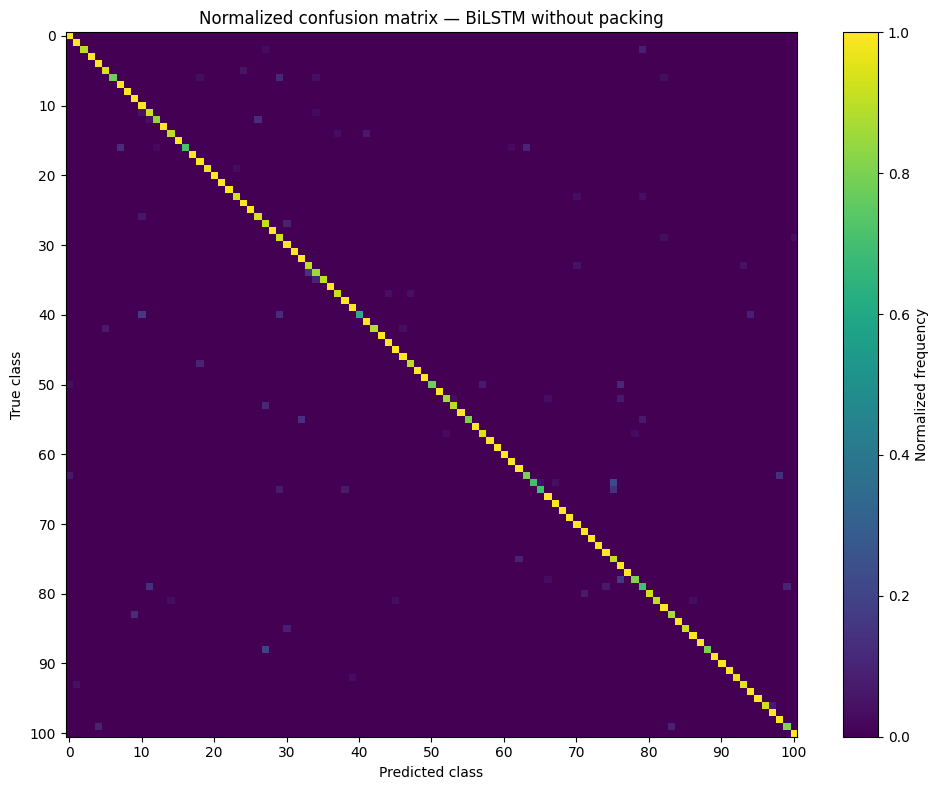

Saved: /kaggle/working/confusion_matrix_bilstm_without_packing.png


In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(
    figsize=(10, 8)
)

image = ax.imshow(
    confusion_normalized,
    aspect="auto"
)

fig.colorbar(
    image,
    ax=ax,
    label="Normalized frequency"
)

tick_positions = np.arange(
    0,
    num_classes,
    10
)

ax.set_xticks(
    tick_positions
)

ax.set_yticks(
    tick_positions
)

ax.set_xlabel(
    "Predicted class"
)

ax.set_ylabel(
    "True class"
)

ax.set_title(
    "Normalized confusion matrix — BiLSTM without packing"
)

fig.tight_layout()

confusion_figure_path = (
    "/kaggle/working/"
    "confusion_matrix_bilstm_without_packing.png"
)

fig.savefig(
    confusion_figure_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved:",
    confusion_figure_path
)


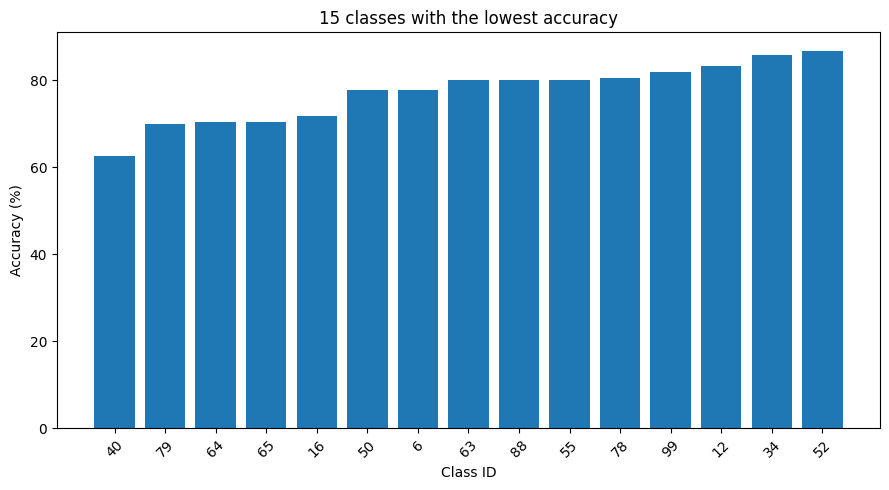

Saved: /kaggle/working/lowest_per_class_accuracy.png


In [ ]:
worst_15 = (
    per_class_results
    .sort_values(
        "accuracy",
        ascending=True
    )
    .head(15)
    .sort_values(
        "accuracy",
        ascending=True
    )
)

fig, ax = plt.subplots(
    figsize=(9, 5)
)

ax.bar(
    worst_15["class_id"].astype(str),
    worst_15["accuracy"] * 100
)

ax.set_xlabel(
    "Class ID"
)

ax.set_ylabel(
    "Accuracy (%)"
)

ax.set_title(
    "15 classes with the lowest accuracy"
)

ax.tick_params(
    axis="x",
    rotation=45
)

fig.tight_layout()

per_class_figure_path = (
    "/kaggle/working/"
    "lowest_per_class_accuracy.png"
)

fig.savefig(
    per_class_figure_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved:",
    per_class_figure_path
)


## 15. Training Curves

Training and validation curves are shown for the Main BiLSTM and the BiLSTM without packed-sequence processing. The curves correspond to the representative seed-42 runs already performed above.

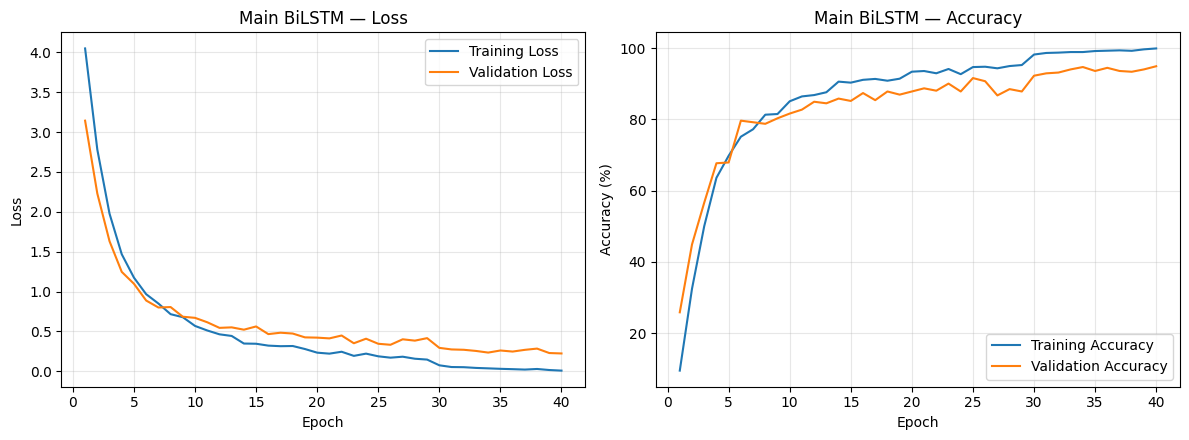

Saved: /kaggle/working/training_curves_main_bilstm.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np


epochs_main = np.arange(
    1,
    len(history_official["train_loss"]) + 1
)


fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4.5)
)


axes[0].plot(
    epochs_main,
    history_official["train_loss"],
    label="Training Loss"
)

axes[0].plot(
    epochs_main,
    history_official["val_loss"],
    label="Validation Loss"
)

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Main BiLSTM — Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)


axes[1].plot(
    epochs_main,
    history_official["train_acc"],
    label="Training Accuracy"
)

axes[1].plot(
    epochs_main,
    history_official["val_acc"],
    label="Validation Accuracy"
)

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title("Main BiLSTM — Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.3)


fig.tight_layout()


main_curve_path = (
    "/kaggle/working/"
    "training_curves_main_bilstm.png"
)

fig.savefig(
    main_curve_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()


print(
    "Saved:",
    main_curve_path
)

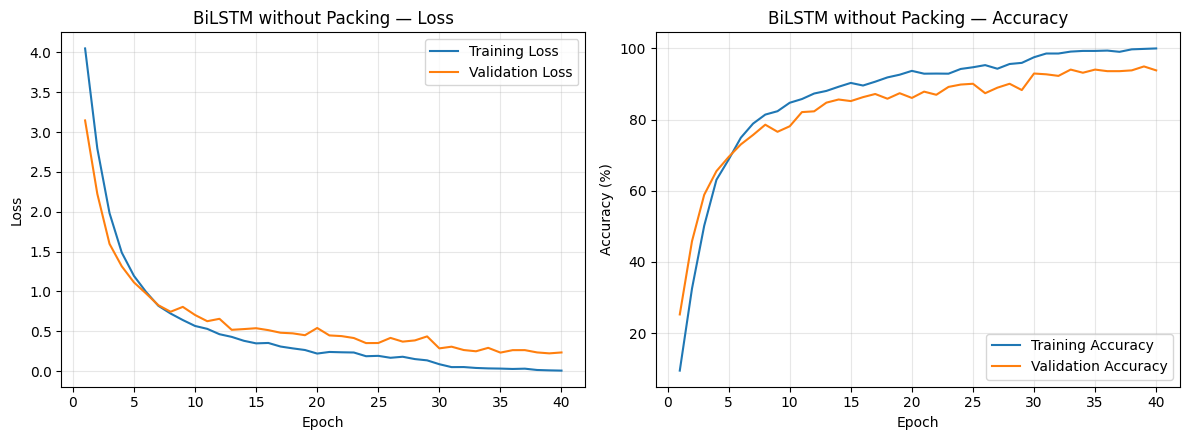

Saved: /kaggle/working/training_curves_bilstm_without_packing.png


In [ ]:
epochs_b = np.arange(
    1,
    len(history_ablation_b["train_loss"]) + 1
)


fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4.5)
)


axes[0].plot(
    epochs_b,
    history_ablation_b["train_loss"],
    label="Training Loss"
)

axes[0].plot(
    epochs_b,
    history_ablation_b["val_loss"],
    label="Validation Loss"
)

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title(
    "BiLSTM without Packing — Loss"
)

axes[0].legend()
axes[0].grid(alpha=0.3)


axes[1].plot(
    epochs_b,
    history_ablation_b["train_acc"],
    label="Training Accuracy"
)

axes[1].plot(
    epochs_b,
    history_ablation_b["val_acc"],
    label="Validation Accuracy"
)

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")

axes[1].set_title(
    "BiLSTM without Packing — Accuracy"
)

axes[1].legend()
axes[1].grid(alpha=0.3)


fig.tight_layout()


ablation_b_curve_path = (
    "/kaggle/working/"
    "training_curves_bilstm_without_packing.png"
)

fig.savefig(
    ablation_b_curve_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()


print(
    "Saved:",
    ablation_b_curve_path
)

In [ ]:
def summarize_training_history(
    name,
    history
):

    train_acc = np.asarray(
        history["train_acc"]
    )

    val_acc = np.asarray(
        history["val_acc"]
    )

    train_loss = np.asarray(
        history["train_loss"]
    )

    val_loss = np.asarray(
        history["val_loss"]
    )


    best_acc_epoch = (
        val_acc.argmax() + 1
    )

    min_loss_epoch = (
        val_loss.argmin() + 1
    )


    return {
        "model": name,

        "epochs": len(
            val_acc
        ),

        "best_val_acc": (
            val_acc.max()
        ),

        "best_val_acc_epoch": (
            best_acc_epoch
        ),

        "train_acc_at_best_epoch": (
            train_acc[
                best_acc_epoch - 1
            ]
        ),

        "accuracy_gap_at_best_epoch": (
            train_acc[
                best_acc_epoch - 1
            ]
            -
            val_acc[
                best_acc_epoch - 1
            ]
        ),

        "min_val_loss": (
            val_loss.min()
        ),

        "min_val_loss_epoch": (
            min_loss_epoch
        )
    }


training_summary = pd.DataFrame([
    summarize_training_history(
        "Main BiLSTM",
        history_official
    ),

    summarize_training_history(
        "BiLSTM without packing",
        history_ablation_b
    )
])


display(
    training_summary.round(4)
)

,model,epochs,best_val_acc,best_val_acc_epoch,train_acc_at_best_epoch,accuracy_gap_at_best_epoch,min_val_loss,min_val_loss_epoch
0,Main BiLSTM,40,94.9115,40,99.9050,4.9935,0.2236,40
1,BiLSTM without packing,40,94.9115,39,99.8417,4.9302,0.2227,39


## 16. Motion-Aware UniLSTM

First-order motion features (`Δx`, `Δy`) are added to the normalized pose representation.


### 16.1 Motion feature extraction


In [ ]:
# Load pose sample
# Remove zero-padded frames
# Sequence-level x/y normalization
# First-order motion features

class ISLRMotionAwareDataset(Dataset):

    def __init__(
        self,
        records,
        X_pose_train,
        y_pose_train,
        X_pose_test,
        y_pose_test
    ):

        self.records = records

        self.X_pose_train = X_pose_train
        self.y_pose_train = y_pose_train

        self.X_pose_test = X_pose_test
        self.y_pose_test = y_pose_test


    def __len__(self):
        return len(self.records)


    def __getitem__(self, idx):

        sample_id, source, real_idx = self.records[idx]


        if source == "pose_train":

            raw_x = self.X_pose_train[real_idx]
            label = int(
                self.y_pose_train[real_idx]
            )

        else:

            raw_x = self.X_pose_test[real_idx]
            label = int(
                self.y_pose_test[real_idx]
            )


        x = np.array(
            raw_x,
            dtype=np.float32,
            copy=True
        )

        x = x[:, :, :, 0]

        x = np.transpose(
            x,
            (1, 2, 0)
        )


        joint_valid = np.any(
            np.abs(x) > 1e-8,
            axis=2
        )

        frame_valid = np.any(
            joint_valid,
            axis=1
        )

        x = x[frame_valid]

        joint_valid = joint_valid[
            frame_valid
        ]

        length = len(x)



        xy = x[:, :, :2].copy()

        if joint_valid.any():

            valid_xy = xy[
                joint_valid
            ]

            center = valid_xy.mean(
                axis=0
            )

            xy = xy - center

            centered_valid = xy[
                joint_valid
            ]

            scale = np.sqrt(
                np.mean(
                    centered_valid ** 2
                )
            )

            if scale > 1e-6:
                xy = xy / scale


        xy[~joint_valid] = 0.0

        x[:, :, :2] = xy



        dxy = np.zeros_like(
            xy,
            dtype=np.float32
        )

        if length > 1:

            delta = (
                xy[1:]
                - xy[:-1]
            )

            motion_valid = (
                joint_valid[1:]
                & joint_valid[:-1]
            )

            delta[
                ~motion_valid
            ] = 0.0

            dxy[1:] = delta



        features = np.concatenate(
            [
                x,
                dxy
            ],
            axis=2
        )


        features = features.reshape(
            length,
            -1
        )

        return (
            torch.from_numpy(
                features
            ),
            torch.tensor(
                label,
                dtype=torch.long
            ),
            length
        )


### 16.2 Motion-aware datasets and DataLoaders


In [ ]:
motion_train_dataset = ISLRMotionAwareDataset(
    official_train_records,
    X_train,
    y_train,
    X_test,
    y_test
)

motion_val_dataset = ISLRMotionAwareDataset(
    official_val_records,
    X_train,
    y_train,
    X_test,
    y_test
)

motion_test_dataset = ISLRMotionAwareDataset(
    official_test_records,
    X_train,
    y_train,
    X_test,
    y_test
)



import random

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


generator_motion = torch.Generator()
generator_motion.manual_seed(SEED)


motion_train_loader = DataLoader(
    motion_train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,
    collate_fn=sequence_collate_fn,
    generator=generator_motion
)

motion_val_loader = DataLoader(
    motion_val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    collate_fn=sequence_collate_fn
)

motion_test_loader = DataLoader(
    motion_test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    collate_fn=sequence_collate_fn
)


sample_x, sample_y, sample_length = (
    motion_train_dataset[0]
)


print(
    "Train / Val / Test:",
    len(motion_train_dataset),
    len(motion_val_dataset),
    len(motion_test_dataset)
)

print(
    "Sample shape:",
    sample_x.shape
)

print(
    "Sample length:",
    sample_length
)

print(
    "Features per frame:",
    sample_x.shape[1]
)


Train / Val / Test: 3158 452 902
Sample shape: torch.Size([60, 335])
Sample length: 60
Features per frame: 335


### 16.3 Motion-aware UniLSTM


In [ ]:
random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)


model_motion = NormalizedMaskedUniLSTM(
    input_size=335,
    hidden_size=128,
    num_classes=101,
    dropout=0.3
).to(device)


num_params_motion = sum(
    p.numel()
    for p in model_motion.parameters()
    if p.requires_grad
)


criterion_motion = nn.CrossEntropyLoss()


optimizer_motion = torch.optim.AdamW(
    model_motion.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)


scheduler_motion = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_motion,
    mode="max",
    factor=0.5,
    patience=3
)


print(
    "Trainable parameters:",
    f"{num_params_motion:,}"
)

print(
    "Input features:",
    335
)

print(
    "Initial LR:",
    optimizer_motion.param_groups[0]["lr"]
)


Trainable parameters: 251,365
Input features: 335
Initial LR: 0.001


### 16.4 Training


In [ ]:
from pathlib import Path

NUM_EPOCHS_MOTION = 40
PATIENCE_MOTION = 8

best_val_acc_motion = 0.0
epochs_without_improvement_motion = 0

history_motion = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

save_path_motion = Path(
    "/kaggle/working/best_motion_aware_unilstm.pt"
)


for epoch in range(
    1,
    NUM_EPOCHS_MOTION + 1
):

    train_loss, train_acc = train_one_epoch_v2(
        model_motion,
        motion_train_loader,
        criterion_motion,
        optimizer_motion,
        device
    )

    val_loss, val_acc = evaluate_v2(
        model_motion,
        motion_val_loader,
        criterion_motion,
        device
    )

    history_motion["train_loss"].append(
        train_loss
    )

    history_motion["train_acc"].append(
        train_acc
    )

    history_motion["val_loss"].append(
        val_loss
    )

    history_motion["val_acc"].append(
        val_acc
    )


    scheduler_motion.step(
        val_acc
    )


    current_lr = (
        optimizer_motion
        .param_groups[0]["lr"]
    )


    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS_MOTION} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.2f}% | "
        f"LR: {current_lr:.6f}"
    )


    if val_acc > best_val_acc_motion:

        best_val_acc_motion = val_acc

        epochs_without_improvement_motion = 0


        torch.save(
            model_motion.state_dict(),
            save_path_motion
        )


        print(
            f"   Best model saved "
            f"(Val Acc = "
            f"{best_val_acc_motion:.2f}%)"
        )

    else:

        epochs_without_improvement_motion += 1


        print(
            f"   No improvement: "
            f"{epochs_without_improvement_motion}/"
            f"{PATIENCE_MOTION}"
        )


    if (
        epochs_without_improvement_motion
        >= PATIENCE_MOTION
    ):

        print("\nEarly stopping")
        break


Epoch 01/40 | Train Loss: 4.2929 | Train Acc: 6.14% | Val Loss: 3.6568 | Val Acc: 17.70% | LR: 0.001000
   Best model saved (Val Acc = 17.70%)
Epoch 02/40 | Train Loss: 3.2441 | Train Acc: 22.45% | Val Loss: 2.7622 | Val Acc: 35.40% | LR: 0.001000
   Best model saved (Val Acc = 35.40%)
Epoch 03/40 | Train Loss: 2.4728 | Train Acc: 40.18% | Val Loss: 2.0841 | Val Acc: 50.88% | LR: 0.001000
   Best model saved (Val Acc = 50.88%)
Epoch 04/40 | Train Loss: 1.9368 | Train Acc: 52.72% | Val Loss: 1.6251 | Val Acc: 61.50% | LR: 0.001000
   Best model saved (Val Acc = 61.50%)
Epoch 05/40 | Train Loss: 1.5889 | Train Acc: 60.42% | Val Loss: 1.3773 | Val Acc: 65.71% | LR: 0.001000
   Best model saved (Val Acc = 65.71%)
Epoch 06/40 | Train Loss: 1.2994 | Train Acc: 68.52% | Val Loss: 1.2294 | Val Acc: 68.58% | LR: 0.001000
   Best model saved (Val Acc = 68.58%)
Epoch 07/40 | Train Loss: 1.0846 | Train Acc: 73.50% | Val Loss: 1.0171 | Val Acc: 73.67% | LR: 0.001000
   Best model saved (Val Acc = 7

### 16.5 Evaluation


In [ ]:
from sklearn.metrics import f1_score


model_motion.load_state_dict(
    torch.load(
        save_path_motion,
        map_location=device,
        weights_only=True
    )
)

model_motion.eval()


test_loss_motion, test_acc_motion = evaluate_v2(
    model_motion,
    motion_test_loader,
    criterion_motion,
    device
)


predictions_motion = []
labels_motion = []


with torch.no_grad():

    for X, y, lengths in motion_test_loader:

        X = X.to(device)

        logits = model_motion(
            X,
            lengths
        )

        predictions = logits.argmax(
            dim=1
        )

        predictions_motion.extend(
            predictions.cpu().numpy()
        )

        labels_motion.extend(
            y.numpy()
        )


predictions_motion = np.asarray(
    predictions_motion
)

labels_motion = np.asarray(
    labels_motion
)


macro_f1_motion = f1_score(
    labels_motion,
    predictions_motion,
    average="macro"
)


accuracy_motion = (
    predictions_motion
    == labels_motion
).mean() * 100


print(
    "===== Proposed Motion-Aware UniLSTM ====="
)

print(
    f"Best Validation Accuracy: "
    f"{best_val_acc_motion:.2f}%"
)

print(
    f"Test Loss: "
    f"{test_loss_motion:.4f}"
)

print(
    f"Test Accuracy: "
    f"{accuracy_motion:.2f}%"
)

print(
    f"Macro-F1: "
    f"{macro_f1_motion:.4f}"
)

print(
    f"Parameters: "
    f"{num_params_motion:,}"
)


print(
    "\n===== Pose-only UniLSTM ====="
)

print(f"Test Accuracy: {accuracy_ablation_c:.2f}%")
print(f"Macro-F1: {macro_f1_ablation_c:.4f}")
print(f"Parameters: {num_params_ablation_c:,}")

===== Proposed Motion-Aware UniLSTM =====
Best Validation Accuracy: 94.25%
Test Loss: 0.2812
Test Accuracy: 92.79%
Macro-F1: 0.9256
Parameters: 251,365

===== Pose-only UniLSTM =====
Test Accuracy: 92.35%
Macro-F1: 0.9196
Parameters: 182,757


## 17. Final Experimental Summary

The main model variants are compared using three independent seeds. Additional ablation experiments are reported separately because they were evaluated as single-run diagnostic experiments.

In [ ]:
import pandas as pd
import numpy as np


model_order = [
    "Main BiLSTM",
    "BiLSTM without packing",
    "UniLSTM"
]


final_robustness_raw = (
    robustness_summary
    .set_index("model")
    .loc[model_order]
    .reset_index()
)


final_robustness_table = pd.DataFrame({
    "Model": final_robustness_raw["model"],

    "Accuracy (%)": [
        f"{mean:.2f} ± {std:.2f}"
        for mean, std in zip(
            final_robustness_raw["accuracy_mean"],
            final_robustness_raw["accuracy_std"]
        )
    ],

    "Macro-F1": [
        f"{mean:.4f} ± {std:.4f}"
        for mean, std in zip(
            final_robustness_raw["macro_f1_mean"],
            final_robustness_raw["macro_f1_std"]
        )
    ],

    "Mean Best Val (%)": (
        final_robustness_raw["best_val_mean"]
        .round(2)
    ),

    "Parameters": (
        final_robustness_raw["parameters"]
        .astype(int)
    )
})


display(
    final_robustness_table
)


final_robustness_raw.to_csv(
    "/kaggle/working/final_robustness_results.csv",
    index=False
)

,Model,Accuracy (%),Macro-F1,Mean Best Val (%),Parameters
0,Main BiLSTM,93.87 ± 0.80,0.9368 ± 0.0090,95.58,365413
1,BiLSTM without packing,94.38 ± 0.23,0.9430 ± 0.0021,95.28,365413
2,UniLSTM,92.87 ± 0.80,0.9243 ± 0.0090,94.62,182757


In [ ]:
single_run_ablations = pd.DataFrame([
    {
        "Experiment": "Without spatial normalization",
        "Test Accuracy (%)": accuracy_ablation_a,
        "Macro-F1": macro_f1_ablation_a,
        "Parameters": num_params_ablation_a
    },

    {
        "Experiment": "UniLSTM + Last Hidden State",
        "Test Accuracy (%)": accuracy_ablation_d,
        "Macro-F1": macro_f1_ablation_d,
        "Parameters": num_params_ablation_d
    },

    {
        "Experiment": "Motion-Aware UniLSTM",
        "Test Accuracy (%)": accuracy_motion,
        "Macro-F1": macro_f1_motion,
        "Parameters": num_params_motion
    }
])


display(
    single_run_ablations.round({
        "Test Accuracy (%)": 2,
        "Macro-F1": 4
    })
)


single_run_ablations.to_csv(
    "/kaggle/working/single_run_ablations.csv",
    index=False
)

,Experiment,Test Accuracy (%),Macro-F1,Parameters
0,Without spatial normalization,91.57,0.9119,365413
1,UniLSTM + Last Hidden State,90.24,0.9025,182757
2,Motion-Aware UniLSTM,92.79,0.9256,251365


In [ ]:
main_result = (
    final_robustness_raw[
        final_robustness_raw["model"]
        == "Main BiLSTM"
    ]
    .iloc[0]
)


no_packing_result = (
    final_robustness_raw[
        final_robustness_raw["model"]
        == "BiLSTM without packing"
    ]
    .iloc[0]
)


unilstm_result = (
    final_robustness_raw[
        final_robustness_raw["model"]
        == "UniLSTM"
    ]
    .iloc[0]
)


packing_accuracy_delta = (
    no_packing_result["accuracy_mean"]
    - main_result["accuracy_mean"]
)


packing_f1_delta = (
    no_packing_result["macro_f1_mean"]
    - main_result["macro_f1_mean"]
)


unilstm_accuracy_drop = (
    main_result["accuracy_mean"]
    - unilstm_result["accuracy_mean"]
)


parameter_reduction = (
    1
    - (
        unilstm_result["parameters"]
        / main_result["parameters"]
    )
) * 100


print("===== Final Experimental Findings =====")

print(
    f"Best mean accuracy: "
    f"{no_packing_result['accuracy_mean']:.2f}% "
    f"+/- {no_packing_result['accuracy_std']:.2f}"
)

print(
    f"Best mean Macro-F1: "
    f"{no_packing_result['macro_f1_mean']:.4f} "
    f"+/- {no_packing_result['macro_f1_std']:.4f}"
)

print(
    f"No-packing vs Main accuracy difference: "
    f"{packing_accuracy_delta:+.2f} percentage points"
)

print(
    f"No-packing vs Main Macro-F1 difference: "
    f"{packing_f1_delta:+.4f}"
)

print(
    f"UniLSTM parameter reduction: "
    f"{parameter_reduction:.2f}%"
)

print(
    f"UniLSTM accuracy drop vs Main: "
    f"{unilstm_accuracy_drop:.2f} percentage points"
)

===== Final Experimental Findings =====
Best mean accuracy: 94.38% +/- 0.23
Best mean Macro-F1: 0.9430 +/- 0.0021
No-packing vs Main accuracy difference: +0.52 percentage points
No-packing vs Main Macro-F1 difference: +0.0062
UniLSTM parameter reduction: 49.99%
UniLSTM accuracy drop vs Main: 1.00 percentage points


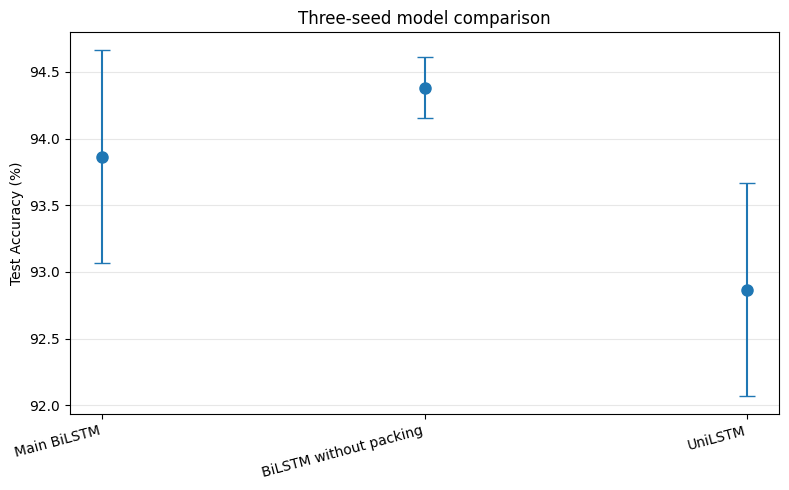

Saved: /kaggle/working/three_seed_model_comparison.png


In [ ]:
import matplotlib.pyplot as plt


fig, ax = plt.subplots(
    figsize=(8, 5)
)


x = np.arange(
    len(final_robustness_raw)
)


ax.errorbar(
    x,
    final_robustness_raw["accuracy_mean"],
    yerr=final_robustness_raw["accuracy_std"],
    fmt="o",
    capsize=6,
    markersize=8
)


ax.set_xticks(x)

ax.set_xticklabels(
    final_robustness_raw["model"],
    rotation=15,
    ha="right"
)


ax.set_ylabel(
    "Test Accuracy (%)"
)

ax.set_title(
    "Three-seed model comparison"
)

ax.grid(
    axis="y",
    alpha=0.3
)


fig.tight_layout()


robustness_figure_path = (
    "/kaggle/working/"
    "three_seed_model_comparison.png"
)


fig.savefig(
    robustness_figure_path,
    dpi=200,
    bbox_inches="tight"
)


plt.show()


print(
    "Saved:",
    robustness_figure_path
)

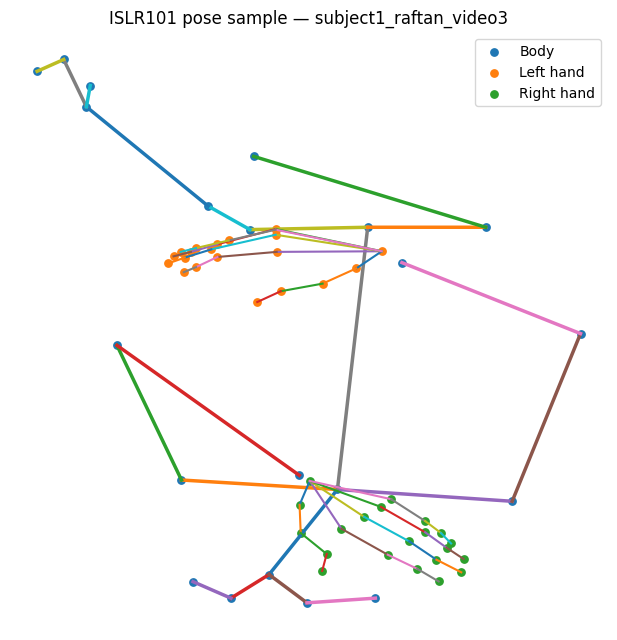

Sample: subject1_raftan_video3
Frame: 49
Valid keypoints: 63 / 67
Saved: /kaggle/working/islr101_sample.png


In [60]:
import numpy as np
import matplotlib.pyplot as plt


BODY_EDGES = [
    (0, 1),
    (1, 2), (2, 3), (3, 4),
    (1, 5), (5, 6), (6, 7),
    (1, 8),
    (8, 9), (9, 10), (10, 11),
    (8, 12), (12, 13), (13, 14),
    (0, 15), (15, 17),
    (0, 16), (16, 18),
    (14, 19), (19, 20), (14, 21),
    (11, 22), (22, 23), (11, 24)
]


HAND_EDGES_LOCAL = [
    (0, 1), (1, 2), (2, 3), (3, 4),
    (0, 5), (5, 6), (6, 7), (7, 8),
    (0, 9), (9, 10), (10, 11), (11, 12),
    (0, 13), (13, 14), (14, 15), (15, 16),
    (0, 17), (17, 18), (18, 19), (19, 20)
]


LEFT_HAND_EDGES = [
    (a + 25, b + 25)
    for a, b in HAND_EDGES_LOCAL
]


RIGHT_HAND_EDGES = [
    (a + 46, b + 46)
    for a, b in HAND_EDGES_LOCAL
]


def get_raw_pose(record):

    sample_id, source, real_idx = record

    if source == "pose_train":
        raw_pose = X_train[real_idx]
    else:
        raw_pose = X_test[real_idx]

    return sample_id, np.asarray(raw_pose)


# Use the sample already selected above if available.
try:
    selected_record = best_record
    selected_frame = best_frame_idx

except NameError:

    best_score = -1
    selected_record = None
    selected_frame = None

    for record in official_test_records:

        sample_id, raw_pose = get_raw_pose(record)

        confidence = raw_pose[
            2, :, :, 0
        ]

        xy = raw_pose[
            :2, :, :, 0
        ]

        valid_xy = np.any(
            np.abs(xy) > 1e-8,
            axis=0
        )

        valid = (
            valid_xy
            & (confidence > 0.10)
        )

        scores = (
            valid.sum(axis=1)
            + confidence.mean(axis=1)
        )

        frame_idx = int(
            np.argmax(scores)
        )

        score = float(
            scores[frame_idx]
        )

        if score > best_score:
            best_score = score
            selected_record = record
            selected_frame = frame_idx


sample_id, raw_pose = get_raw_pose(
    selected_record
)


points = raw_pose[
    :2,
    selected_frame,
    :,
    0
].T.astype(float)


confidence = raw_pose[
    2,
    selected_frame,
    :,
    0
].astype(float)


valid = (
    (confidence > 0.10)
    & np.any(
        np.abs(points) > 1e-8,
        axis=1
    )
)


valid_points = points[valid]


# Normalize only for visualization.
x_min, y_min = valid_points.min(
    axis=0
)

x_max, y_max = valid_points.max(
    axis=0
)


x_range = max(
    x_max - x_min,
    1e-6
)

y_range = max(
    y_max - y_min,
    1e-6
)


plot_points = points.copy()

plot_points[:, 0] = (
    plot_points[:, 0] - x_min
) / x_range

plot_points[:, 1] = (
    plot_points[:, 1] - y_min
) / y_range


def point_valid(i):
    return bool(valid[i])


def draw_edges(
    ax,
    edges,
    linewidth=2
):

    for a, b in edges:

        if (
            point_valid(a)
            and point_valid(b)
        ):

            ax.plot(
                [
                    plot_points[a, 0],
                    plot_points[b, 0]
                ],
                [
                    plot_points[a, 1],
                    plot_points[b, 1]
                ],
                linewidth=linewidth
            )


fig, ax = plt.subplots(
    figsize=(6.5, 6.5)
)


draw_edges(
    ax,
    BODY_EDGES,
    linewidth=2.5
)

draw_edges(
    ax,
    LEFT_HAND_EDGES,
    linewidth=1.5
)

draw_edges(
    ax,
    RIGHT_HAND_EDGES,
    linewidth=1.5
)


body_ids = np.arange(0, 25)
left_hand_ids = np.arange(25, 46)
right_hand_ids = np.arange(46, 67)


for ids, label in [
    (body_ids, "Body"),
    (left_hand_ids, "Left hand"),
    (right_hand_ids, "Right hand")
]:

    ids = ids[
        valid[ids]
    ]

    ax.scatter(
        plot_points[ids, 0],
        plot_points[ids, 1],
        s=28,
        label=label
    )


ax.invert_yaxis()

ax.set_aspect(
    "equal"
)

ax.axis(
    "off"
)


ax.set_title(
    f"ISLR101 pose sample — {sample_id}"
)


ax.legend(
    loc="upper right"
)


fig.tight_layout()


output_path = (
    "/kaggle/working/"
    "islr101_sample.png"
)


fig.savefig(
    output_path,
    dpi=250,
    bbox_inches="tight"
)


plt.show()


print(
    "Sample:",
    sample_id
)

print(
    "Frame:",
    selected_frame
)

print(
    "Valid keypoints:",
    int(valid.sum()),
    "/ 67"
)

print(
    "Saved:",
    output_path
)